## Project Summary — Credit Card Customer Churn Prediction

**Objective:** Predict credit card customer attrition to enable proactive retention, optimizing for Recall/F1 given the asymmetric cost of missed churners.

**Data:** BankChurners dataset, 10,127 customers, 20 features, 16.07% churn rate.

**Key EDA findings:** Transaction activity (`Total_Trans_Ct`) is the strongest single predictor (r=−0.37); low product depth + low transaction activity compound to an 88.6% churn rate (n=483); Credit_Limit floor value (1438.3) is a real risk signal; Card_Category and Marital_Status carry negligible signal (confirmed via Chi-square).

**Feature engineering:** Built `is_min_credit_limit` and `high_risk_segment` (strongest engineered feature, r=0.442); log-transformed skewed monetary features; ordinal/one-hot encoded categoricals; discovered and documented a structural Income/Gender confound (income bands $60K+ are 100% male in this dataset).

**Modeling:** Compared Logistic Regression, KNN, Random Forest, and XGBoost. XGBoost selected as final model (F1=0.92, Recall=0.87-0.91 depending on threshold, ROC-AUC=0.993), validated via 5-fold stratified CV with per-fold threshold optimization. Hyperparameter tuning yielded no significant improvement over defaults — feature engineering, not tuning, drove performance.

**Final threshold:** 0.30, selected via leakage-safe out-of-fold cross-validation on training data only.

**Explainability & fairness:** SHAP confirmed EDA findings almost exactly (`Total_Trans_Ct`, `Total_Trans_Amt`, `Total_Revolving_Bal` dominate). Gender fairness audit found no evidence of systematic bias, with a documented caveat that the Income/Gender confound structurally limits what the audit can verify.

**Error analysis:** Model reliably catches gradual, behaviorally-visible churn but has a genuine blind spot for engaged, high-value customers who churn suddenly — a limitation from the feature set, not the model, and one that warrants human review as a complement to the model in production.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                               recall_score, f1_score, precision_score, 
                               accuracy_score, roc_auc_score,average_precision_score,roc_curve)
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import shap
from sklearn.pipeline import Pipeline
import joblib
args = ['display.max_columns', None,
        'display.max_rows', 100,
        'display.float_format', '{:.2f}'.format]
pd.set_option(*args)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Setup complete.")

Setup complete.


d:\Data Projects\End_to_End_ML\my_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================
# Load and Initial Clean
# ============================================

df = pd.read_csv('../Data/Bank_churn.csv')

### dropping the column which was copy of index
if (df.index == df['Unnamed: 0']).all():
    df = df.drop(columns='Unnamed: 0')
### Clinentnum is just an identifier not a predictor. so we drop it from the dataset.
df.drop(columns='CLIENTNUM',inplace=True)
print('-'*60)
print(f'The shape of the dataframe is {df.shape}')
print(f'Total No. of rows : {df.shape[0]}')
print(f'Total No. of columns : {df.shape[1]-1}')
df.head(10)

------------------------------------------------------------
The shape of the dataframe is (10127, 20)
Total No. of rows : 10127
Total No. of columns : 19


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.00,777,11914.00,1.33,1144,42,1.62,0.06
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.00,864,7392.00,1.54,1291,33,3.71,0.10
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.00,0,3418.00,2.59,1887,20,2.33,0.00
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.00,2517,796.00,1.41,1171,20,2.33,0.76
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.00,0,4716.00,2.17,816,28,2.50,0.00
5,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,3,1,2,4010.00,1247,2763.00,1.38,1088,24,0.85,0.31
6,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,6,1,3,34516.00,2264,32252.00,1.98,1330,31,0.72,0.07
7,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,2,2,2,29081.00,1396,27685.00,2.20,1538,36,0.71,0.05
8,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,5,2,0,22352.00,2517,19835.00,3.35,1350,24,1.18,0.11
9,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,6,3,3,11656.00,1677,9979.00,1.52,1441,32,0.88,0.14


## Phase 2: Data Understanding

In [3]:
# ----------------------------------------
# Structure - Data Type and Non-null count
# ----------------------------------------
print("=" * 70)
print("2. DATA TYPES AND NON-NULL COUNTS")
print("=" * 70)
df.info()

2. DATA TYPES AND NON-NULL COUNTS
<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  str    
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  str    
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  str    
 5   Marital_Status            10127 non-null  str    
 6   Income_Category           10127 non-null  str    
 7   Card_Category             10127 non-null  str    
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-nu

In [4]:
# Point 3: Numerical summary
print("=" * 70)
print("3. NUMERICAL FEATURES SUMMARY")
print("=" * 70)
df.describe( )

3. NUMERICAL FEATURES SUMMARY


,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86,0.71,0.27
std,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47,0.24,0.28
min,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00
25%,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00,0.58,0.02
50%,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00,0.70,0.18
75%,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00,0.82,0.50
max,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00,3.71,1.00


In [5]:
## Categorical Summary
print("=" * 70)
print("CATEGORICAL FEATURES SUMMARY")
print("=" * 70)
df.describe(include='object')


CATEGORICAL FEATURES SUMMARY


C:\Users\uSer\AppData\Local\Temp\ipykernel_23604\3813182784.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
count,10127,10127,10127,10127,10127,10127
unique,2,2,7,4,6,4
top,Existing Customer,F,Graduate,Married,Less than $40K,Blue
freq,8500,5358,3128,4687,3561,9436


In [6]:
### Null count dataframe
nulls = df.isnull().sum()
null_pct = round(nulls*100/len(df),2)
missing_df = pd.DataFrame({'Total Null':nulls,
                           'Null(%)':null_pct})
missing_df

,Total Null,Null(%)
Attrition_Flag,0,0.00
Customer_Age,0,0.00
Gender,0,0.00
Dependent_count,0,0.00
Education_Level,0,0.00
Marital_Status,0,0.00
Income_Category,0,0.00
Card_Category,0,0.00
Months_on_book,0,0.00
Total_Relationship_Count,0,0.00


#### No null values throughout the dataframe

In [7]:
# ============================================
# Cell 4: Target Variable Distribution
# ============================================
imbalance_value = df['Attrition_Flag'].value_counts()
imbalance_pct = df['Attrition_Flag'].value_counts(normalize=True)
imbalance_df = pd.DataFrame({'Count':imbalance_value,
                             'Percentage': imbalance_pct})
print(imbalance_df)
print(f'\n Imbalance Ratio : {(imbalance_pct.max() /imbalance_pct.min()).round(2)}')

                   Count  Percentage
Attrition_Flag                      
Existing Customer   8500        0.84
Attrited Customer   1627        0.16

 Imbalance Ratio : 5.22


C:\Users\uSer\AppData\Local\Temp\ipykernel_23604\1855275459.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df = df.select_dtypes(include='object')


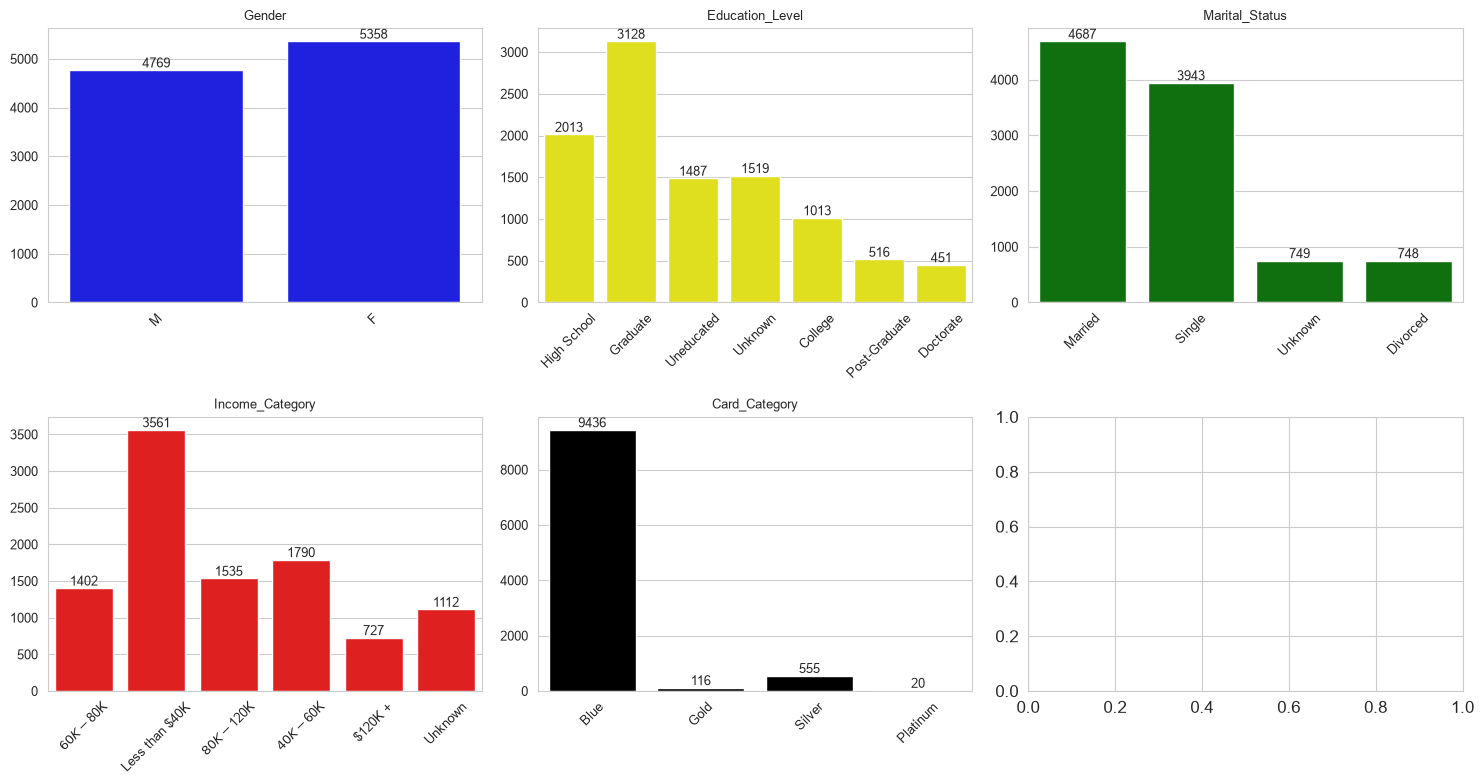

In [8]:
### Categorical Value Counts
cat_df = df.select_dtypes(include='object')
cat_df = cat_df.drop(columns='Attrition_Flag')

label_kwargs = {'labelrotation':45,
                'labelsize':9}
color_kwargs = {'Gender':'Blue',
                'Education_Level':'Yellow',
                'Marital_Status': 'Green',
                'Income Category':'Red',
                'Card Category' : 'Black'
               }
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col,ax,color in zip(cat_df.columns,axes.flat,color_kwargs.values()):
    sns.countplot(data=cat_df,x=col,ax=ax,color=color)
    for container in ax.containers:
        ax.bar_label(container,fontsize = 9)
    ax.set_title(col,fontsize = 9)
    ax.tick_params(axis='x',**label_kwargs)
    ax.tick_params(axis='y',labelsize = 9)
    ax.set(xlabel='',ylabel='')
plt.tight_layout()

In [9]:
unknown_cat_cols = []
for col in cat_df.columns:
    valcounts = cat_df[col].value_counts()
    if 'Unknown' in valcounts.index:
        pct = valcounts['Unknown'] / valcounts.sum()
        print(f"Unknown in {col}: {pct:.2%}")
        unknown_cat_cols.append(col)
# =================================================
# Investigate: Does "Unknown" correlate with churn?
# =================================================
for col in unknown_cat_cols:
    ct = pd.crosstab(df[col],df['Attrition_Flag'], normalize='index')*100
    print(ct.round(2))


Unknown in Education_Level: 15.00%
Unknown in Marital_Status: 7.40%
Unknown in Income_Category: 10.98%
Attrition_Flag   Attrited Customer  Existing Customer
Education_Level                                      
College                      15.20              84.80
Doctorate                    21.06              78.94
Graduate                     15.57              84.43
High School                  15.20              84.80
Post-Graduate                17.83              82.17
Uneducated                   15.94              84.06
Unknown                      16.85              83.15
Attrition_Flag  Attrited Customer  Existing Customer
Marital_Status                                      
Divorced                    16.18              83.82
Married                     15.13              84.87
Single                      16.94              83.06
Unknown                     17.22              82.78
Attrition_Flag   Attrited Customer  Existing Customer
Income_Category                        

In [10]:
# ============================================
# Investigate the Credit_Limit floor value
# ============================================

floor_value = df[df['Credit_Limit'] == df['Credit_Limit'].min()]['Attrition_Flag']
print('-'*60)
print(f'Rows with minimum credit limit : {len(floor_value)}')
print('-'*60)
x = floor_value.value_counts(normalize=True)
print(x)

------------------------------------------------------------
Rows with minimum credit limit : 507
------------------------------------------------------------
Attrition_Flag
Existing Customer   0.76
Attrited Customer   0.24
Name: proportion, dtype: float64


## Phase 3 : Data Cleaning

### Target Variable Encoding
#### We need a numeric target for modelling, but we also want to preserve the readable version for EDA plots

In [11]:
churn_encoder= {'Existing Customer':0,
                'Attrited Customer':1}
df['churn'] = df['Attrition_Flag'].map(churn_encoder)
## verifying the mapping
churn_encoder_validation = df[['Attrition_Flag','churn']].drop_duplicates()
print(churn_encoder_validation)
if len(churn_encoder_validation) == 2:
    print('Prediction Label encoding validated')
else:
    print('label encoding failed')

       Attrition_Flag  churn
0   Existing Customer      0
21  Attrited Customer      1
Prediction Label encoding validated


### Duplicate Detection

In [12]:
print(f'Fully duplicate rows : {df.duplicated().sum()}')
print(f"Fully duplicate rows excluding churn : {df.drop(columns=['churn']).duplicated().sum()}")

Fully duplicate rows : 0
Fully duplicate rows excluding churn : 0


### Outlier Detection

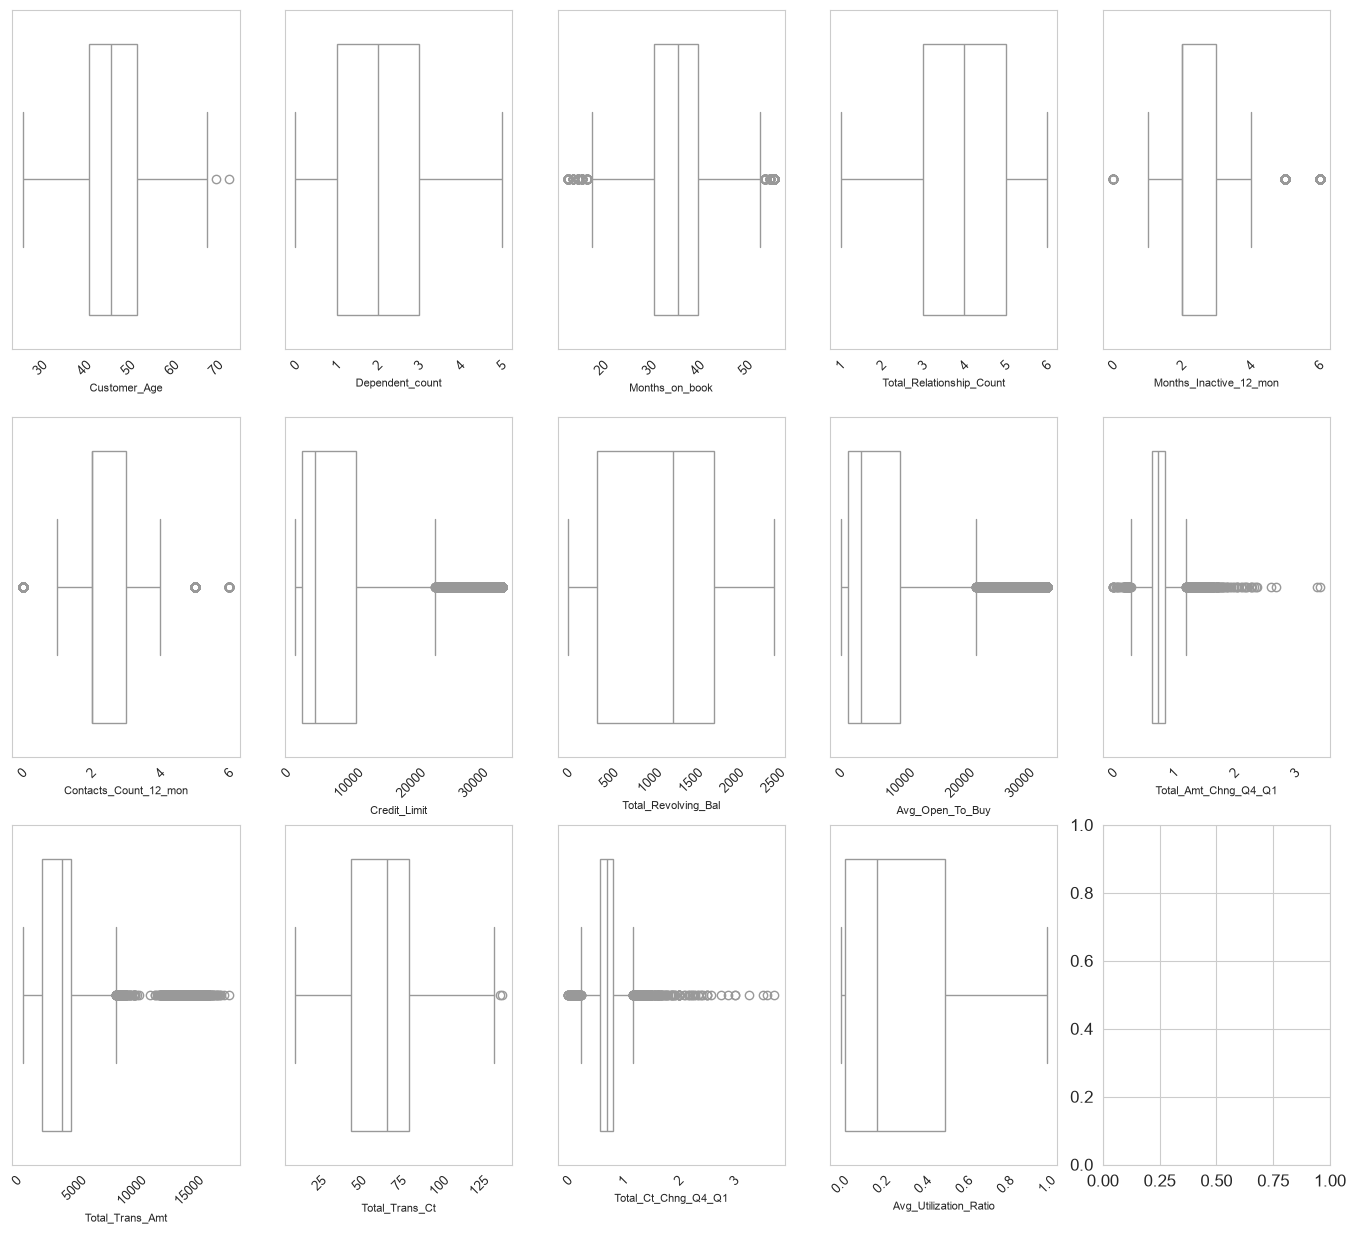

In [13]:
numeric_cols = df.select_dtypes(['integer','float']).columns.to_list()
numeric_cols.remove('churn')
fig,axes = plt.subplots(3,5,figsize = (17,15)) 
for col,ax in zip(numeric_cols,axes.flat):
    sns.boxplot(df,x=col,ax=ax,color = (1, 1, 1, 1))
    ax.set_xlabel(col,fontsize = 8)
    ax.tick_params(axis='x',**label_kwargs)
    ax.tick_params(axis='y',labelsize = 9)
    ax.grid(visible=False)
plt.show()
#for col in numeric_cols:
#    sns.boxplot(data=df,x=col)
#    plt.show()


In [14]:
outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5* IQR
    upper_bound = Q3 + 1.5* IQR
    outliers = df[(df[col]  < lower_bound) | (df[col] > upper_bound)]
    outlier_summary.append({ 
                            'Feature':col,
                            'Lower Bound' : lower_bound.round(2),
                            'Upper Bound' : upper_bound.round(2),
                            'Outlier Count' : len(outliers),
                            'Outlier(%)' : round(len(outliers)*100/len(df),2)
                           })
outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Outlier(%)',ascending=False)
outlier_df

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier(%)
6,Credit_Limit,-10213.75,23836.25,984,9.72
8,Avg_Open_To_Buy,-11477.25,22660.75,963,9.51
10,Total_Trans_Amt,-1722.75,8619.25,896,8.85
5,Contacts_Count_12_mon,0.50,4.50,629,6.21
9,Total_Amt_Chng_Q4_Q1,0.29,1.20,396,3.91
12,Total_Ct_Chng_Q4_Q1,0.23,1.17,394,3.89
2,Months_on_book,17.50,53.50,386,3.81
4,Months_Inactive_12_mon,0.50,4.50,331,3.27
0,Customer_Age,24.50,68.50,2,0.02
11,Total_Trans_Ct,-9.00,135.00,2,0.02


### Logical Consistency Checks
#### Checking whether related columns are internally consistent

In [15]:
# Check 1: Avg_Open_To_Buy should equal Credit_Limit - Total_Revolving_Bal
checks = {}
df['_check_open_to_buy'] = df['Credit_Limit'] - df['Total_Revolving_Bal']
mismatch = (df['_check_open_to_buy'] - df['Avg_Open_To_Buy']).abs() > 1
checks['open_to_buy_consistency']  = mismatch.sum()

# Check 2: Avg_Utilization_Ratio should be between 0 and 1
checks['Utilization Ratio out of [0,1] range'] = ((df['Avg_Utilization_Ratio'] < 0) | (df['Avg_Utilization_Ratio'] > 1)).sum()

# Check 3: Utilization Ratio should roughly equal Total_Revolving_Bal / Credit_Limit
df['_check_util'] = df['Total_Revolving_Bal'] / df['Credit_Limit']
util_mismatch = (df['_check_util'] - df['Avg_Utilization_Ratio']).abs() > 0.05
checks['Utilization Ratio formula consistency'] = util_mismatch.sum()

# Check 4: Age should be reasonable for a credit card holder (e.g., 18-100)
checks['Age out of plausible range'] = ((df['Customer_Age'] < 18) | (df['Customer_Age'] > 100)).sum()

# Check 5: Months_on_book shouldn't exceed a reasonable max relative to age
# (e.g., can't have been a customer for more years than plausible given age)
checks['Months_on_book vs Age implausible'] = (df['Months_on_book'] > (df['Customer_Age'] - 18) * 12).sum()

for check,count in checks.items():
    if count == 0:
        status = 'Pass'
    else:
        status = 'Fail'
    print(f'{check}:{status}')
df.drop(columns=['_check_open_to_buy','_check_util'],inplace=True)
checks

open_to_buy_consistency:Pass
Utilization Ratio out of [0,1] range:Pass
Utilization Ratio formula consistency:Pass
Age out of plausible range:Pass
Months_on_book vs Age implausible:Pass


{'open_to_buy_consistency': np.int64(0),
 'Utilization Ratio out of [0,1] range': np.int64(0),
 'Utilization Ratio formula consistency': np.int64(0),
 'Age out of plausible range': np.int64(0),
 'Months_on_book vs Age implausible': np.int64(0)}

In [16]:
# ============================================
# Cell: Data Quality Report Summary
# ============================================

print("=" * 70)
print("PHASE 3 DATA QUALITY REPORT")
print("=" * 70)
print(f"""
Dataset: BankChurners (Credit Card Customer Attrition)
Final Shape: {df.shape}

STRUCTURAL CLEANUP:
- Dropped: CLIENTNUM (identifier, no predictive value)
- Dropped: 2 trailing Naive Bayes columns (data leakage from prior analysis)
- Dropped: unnamed index column

TARGET VARIABLE:
- Attrition_Flag encoded to binary 'Churn' (1=Attrited, 0=Existing)
- Class distribution: {(df['churn'].mean()*100):.2f}% Attrited / {(100-df['churn'].mean()*100):.2f}% Existing

MISSING VALUES:
- No traditional NaN values present
- "Unknown" present in Education_Level, Marital_Status, Income_Category
- Decision: Unknown retained as valid category (not correlated with target)

DUPLICATES:
- {df.duplicated().sum()} fully duplicate rows found

DATA TYPES:
- All columns verified as appropriate types for their content

OUTLIERS:
- Detected via IQR method, NOT yet removed
- Decision pending visual inspection in Phase 4

ENGINEERED FLAGS (created for reference, formal engineering in Phase 5):
- is_min_credit_limit: flags Credit_Limit == 1438.3 floor value (24% vs 16% base attrition rate)
""")

PHASE 3 DATA QUALITY REPORT

Dataset: BankChurners (Credit Card Customer Attrition)
Final Shape: (10127, 21)

STRUCTURAL CLEANUP:
- Dropped: CLIENTNUM (identifier, no predictive value)
- Dropped: 2 trailing Naive Bayes columns (data leakage from prior analysis)
- Dropped: unnamed index column

TARGET VARIABLE:
- Attrition_Flag encoded to binary 'Churn' (1=Attrited, 0=Existing)
- Class distribution: 16.07% Attrited / 83.93% Existing

MISSING VALUES:
- No traditional NaN values present
- "Unknown" present in Education_Level, Marital_Status, Income_Category
- Decision: Unknown retained as valid category (not correlated with target)

DUPLICATES:
- 0 fully duplicate rows found

DATA TYPES:
- All columns verified as appropriate types for their content

OUTLIERS:
- Detected via IQR method, NOT yet removed
- Decision pending visual inspection in Phase 4

ENGINEERED FLAGS (created for reference, formal engineering in Phase 5):
- is_min_credit_limit: flags Credit_Limit == 1438.3 floor value (24%

### Phase 4 : EDS (Exploratory Data Analysis)

#### Numeric Feature Distribution

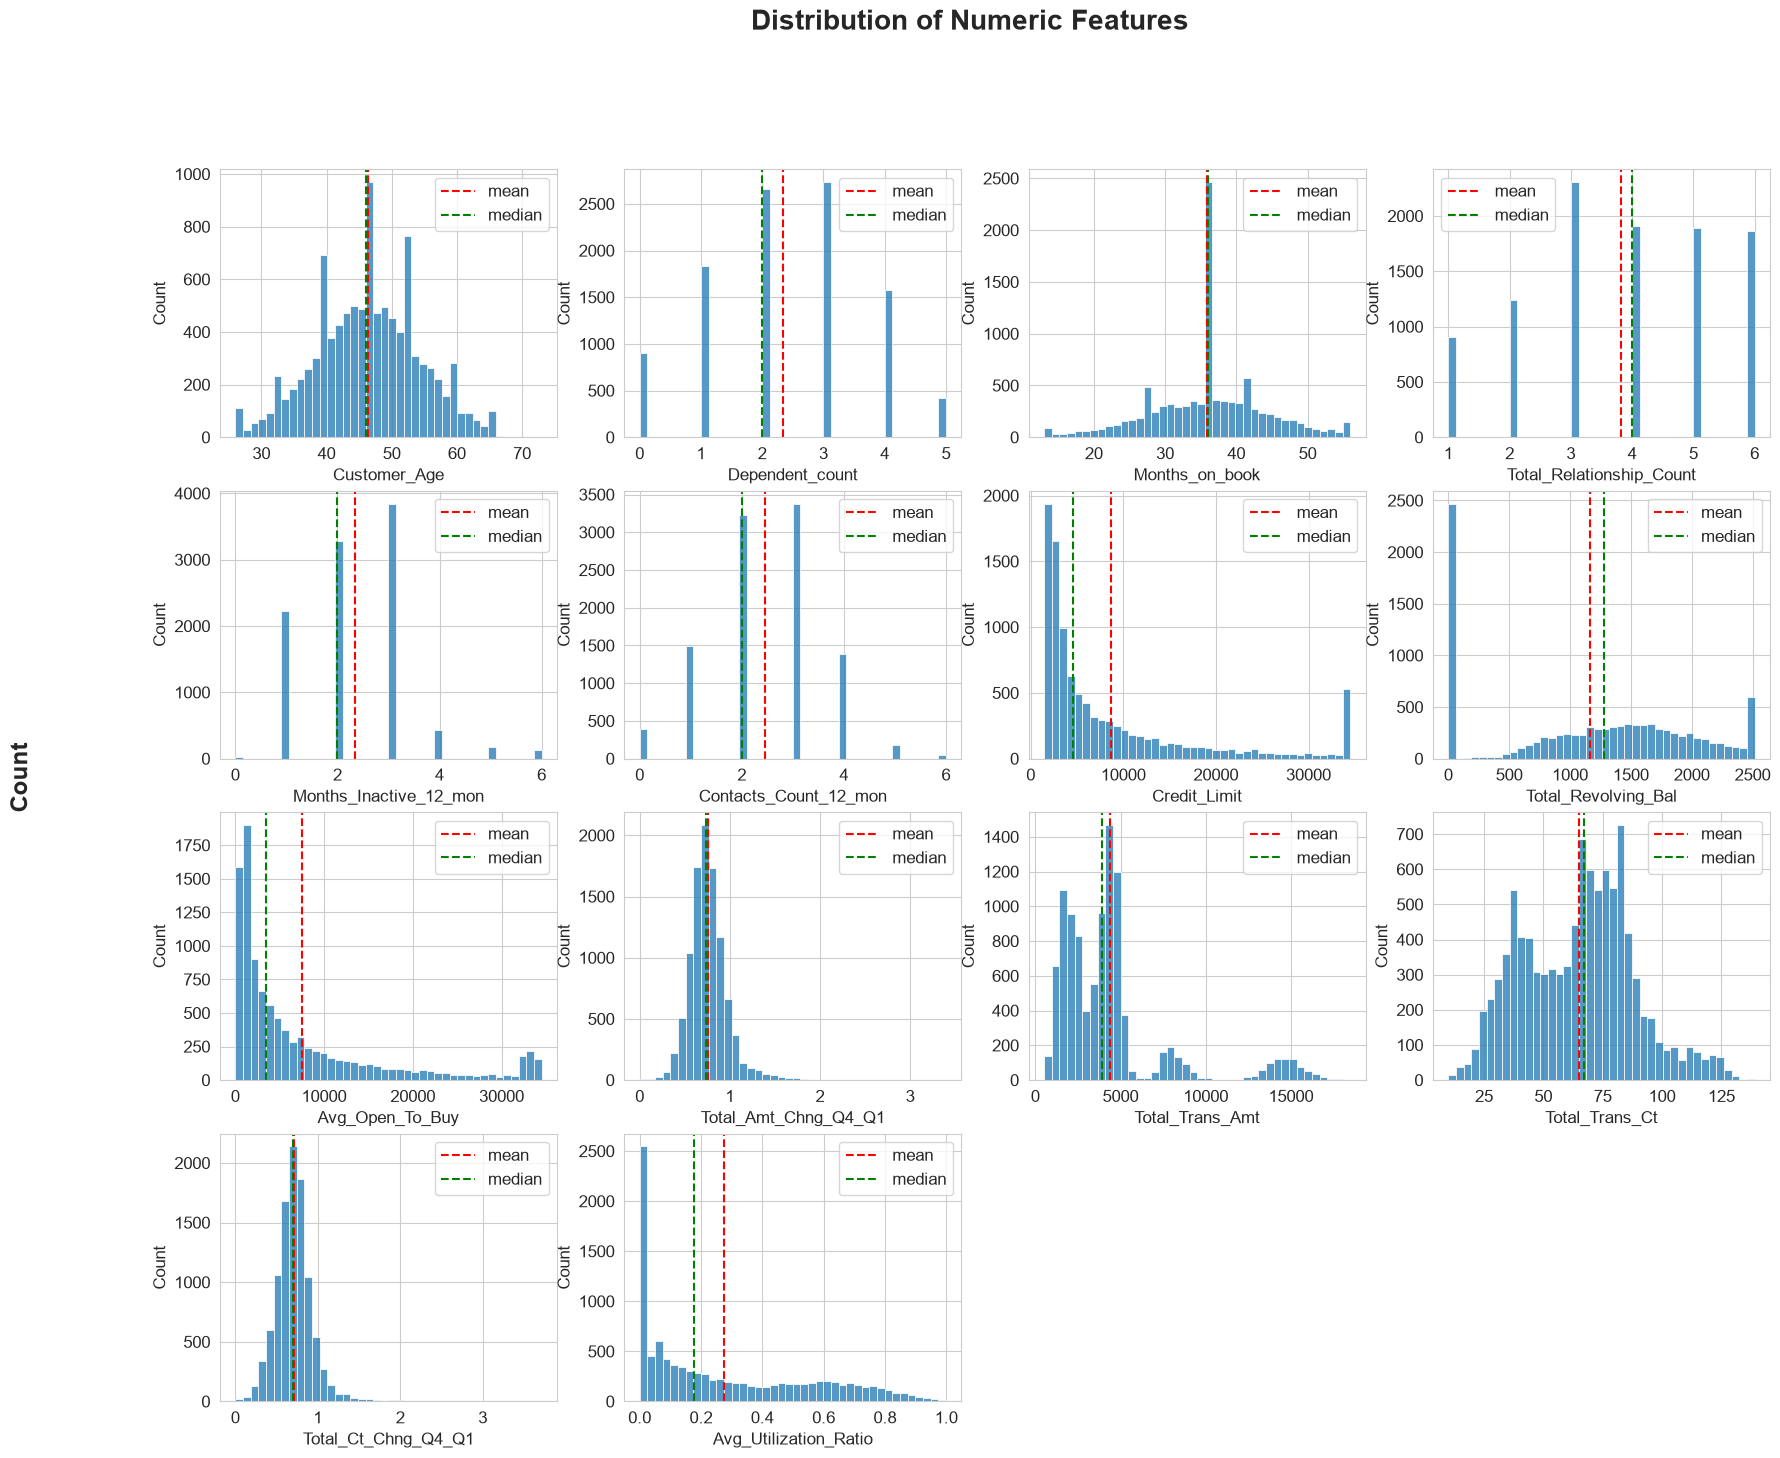

In [17]:
fig,axes =  plt.subplots(4,4,figsize = (20,16))
fig.suptitle("Distribution of Numeric Features", fontsize=20, fontweight="bold")
fig.supylabel('Count',fontweight = "bold",fontsize = 17)
axes = axes.flatten()
linestyle_kwargs = {'ls': '--',
                    'ms': 12}
for ax,col in zip(axes,numeric_cols):
    sns.histplot(df[col],bins=40,ax=ax)
    ax.axvline(df[col].mean(),color = 'red',**linestyle_kwargs)
    ax.axvline(df[col].median(),color = 'green',**linestyle_kwargs)
    ax.legend(['mean','median'])

for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

    

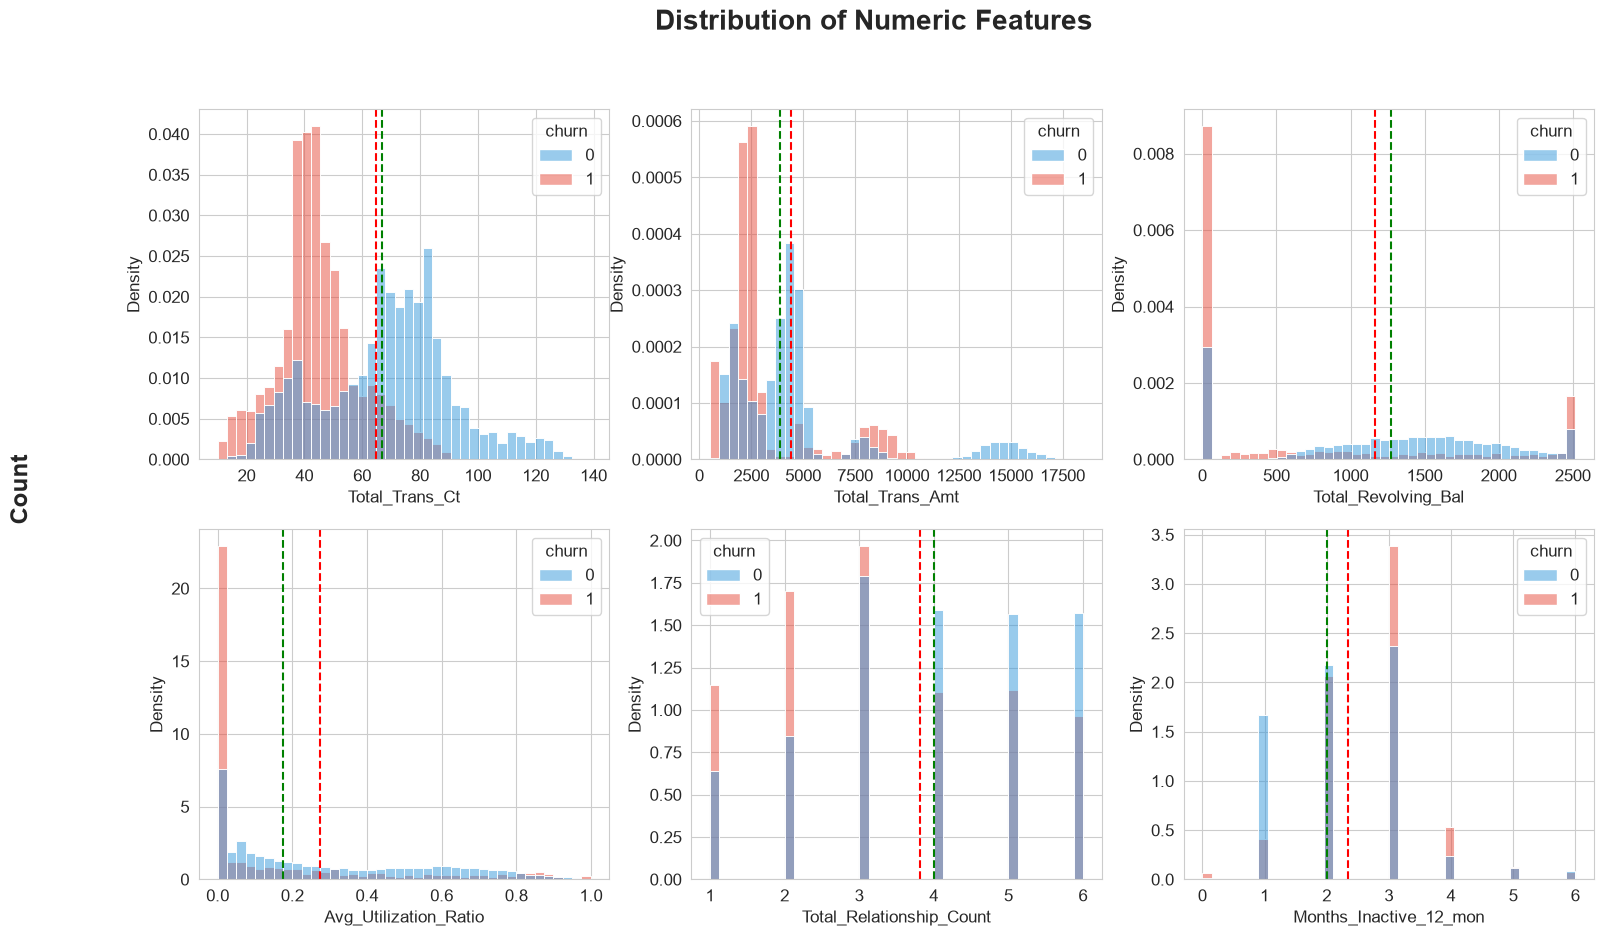

In [18]:
key_features = ['Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Revolving_Bal', 
                 'Avg_Utilization_Ratio', 'Total_Relationship_Count', 'Months_Inactive_12_mon']
fig,axes =  plt.subplots(2,3,figsize = (18,10))
fig.suptitle("Distribution of Numeric Features", fontsize=20, fontweight="bold")
fig.supylabel('Count',fontweight = "bold",fontsize = 17)
axes = axes.flatten()
linestyle_kwargs = {'ls': '--',
                    'ms': 12}

palette = {
 0: '#3498db', # Non-churn
 1: '#e74c3c' # Churn
}


for ax,col in zip(axes,key_features):
    sns.histplot(data=df,x= col,bins=40,ax=ax,hue='churn',stat='density',common_norm=False,palette=palette)
    ax.axvline(df[col].mean(),color = 'red',**linestyle_kwargs)
    ax.axvline(df[col].median(),color = 'green',**linestyle_kwargs)
    ax.get_legend_handles_labels()

### Quantifying Relationship with Correlation Heatmap

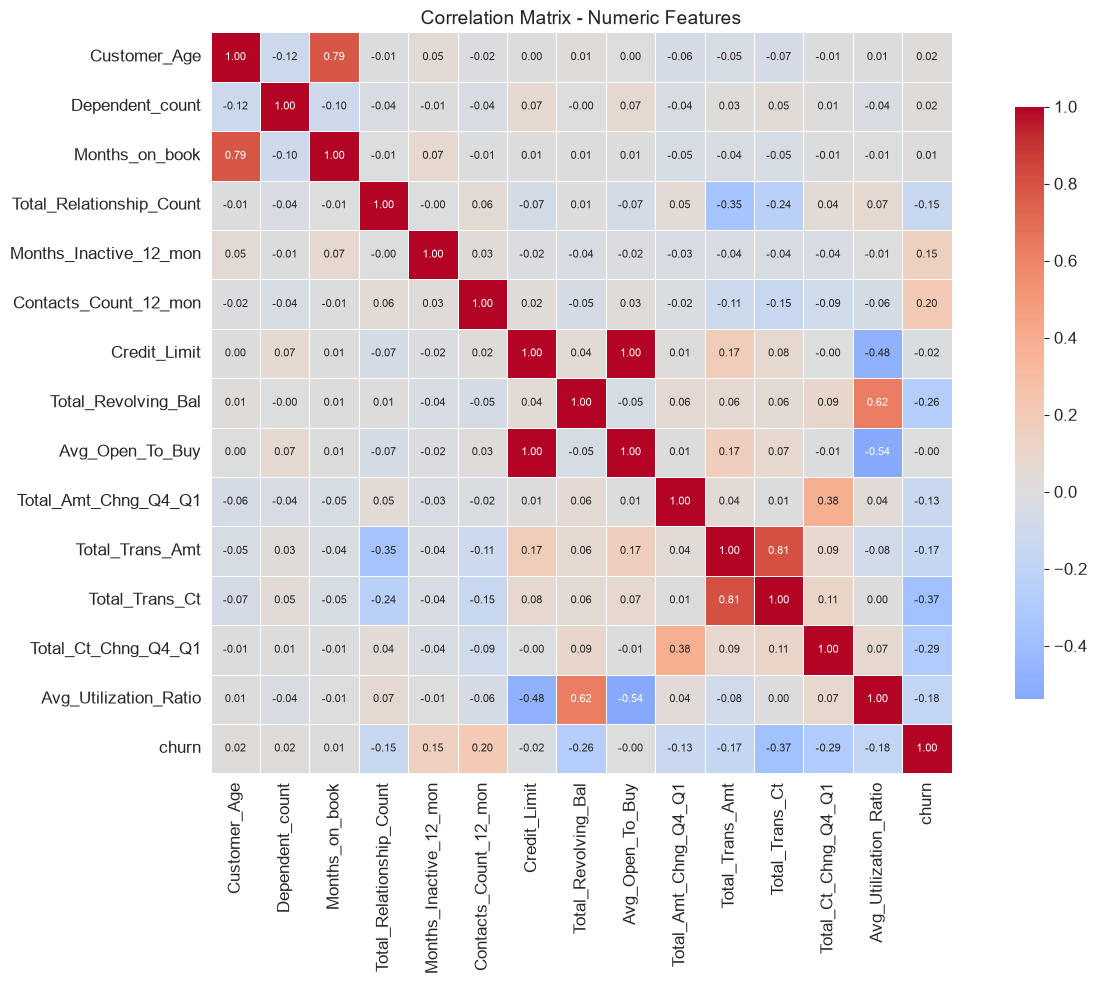

In [19]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
plt.figure(figsize=(14,10))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, 
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# ============================================
# Cell: Correlation with Churn specifically, ranked
# ============================================
target_corr = corr_matrix[['churn']].drop('churn')
print('-'*60)
print("Feature correlation with Churn (ranked by strength)")
print('-'*60)
print(target_corr.sort_values(by='churn',ascending=False))

------------------------------------------------------------
Feature correlation with Churn (ranked by strength)
------------------------------------------------------------
                          churn
Contacts_Count_12_mon      0.20
Months_Inactive_12_mon     0.15
Dependent_count            0.02
Customer_Age               0.02
Months_on_book             0.01
Avg_Open_To_Buy           -0.00
Credit_Limit              -0.02
Total_Amt_Chng_Q4_Q1      -0.13
Total_Relationship_Count  -0.15
Total_Trans_Amt           -0.17
Avg_Utilization_Ratio     -0.18
Total_Revolving_Bal       -0.26
Total_Ct_Chng_Q4_Q1       -0.29
Total_Trans_Ct            -0.37


In [21]:
# ============================================
# Cell: Flag high multicollinearity pairs (|r| > 0.7)
# ============================================
corr_matrix

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,churn
Customer_Age,1.00,-0.12,0.79,-0.01,0.05,-0.02,0.00,0.01,0.00,-0.06,-0.05,-0.07,-0.01,0.01,0.02
Dependent_count,-0.12,1.00,-0.10,-0.04,-0.01,-0.04,0.07,-0.00,0.07,-0.04,0.03,0.05,0.01,-0.04,0.02
Months_on_book,0.79,-0.10,1.00,-0.01,0.07,-0.01,0.01,0.01,0.01,-0.05,-0.04,-0.05,-0.01,-0.01,0.01
Total_Relationship_Count,-0.01,-0.04,-0.01,1.00,-0.00,0.06,-0.07,0.01,-0.07,0.05,-0.35,-0.24,0.04,0.07,-0.15
Months_Inactive_12_mon,0.05,-0.01,0.07,-0.00,1.00,0.03,-0.02,-0.04,-0.02,-0.03,-0.04,-0.04,-0.04,-0.01,0.15
Contacts_Count_12_mon,-0.02,-0.04,-0.01,0.06,0.03,1.00,0.02,-0.05,0.03,-0.02,-0.11,-0.15,-0.09,-0.06,0.20
Credit_Limit,0.00,0.07,0.01,-0.07,-0.02,0.02,1.00,0.04,1.00,0.01,0.17,0.08,-0.00,-0.48,-0.02
Total_Revolving_Bal,0.01,-0.00,0.01,0.01,-0.04,-0.05,0.04,1.00,-0.05,0.06,0.06,0.06,0.09,0.62,-0.26
Avg_Open_To_Buy,0.00,0.07,0.01,-0.07,-0.02,0.03,1.00,-0.05,1.00,0.01,0.17,0.07,-0.01,-0.54,-0.00
Total_Amt_Chng_Q4_Q1,-0.06,-0.04,-0.05,0.05,-0.03,-0.02,0.01,0.06,0.01,1.00,0.04,0.01,0.38,0.04,-0.13


In [22]:
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1,len(corr_matrix.columns)):
        val = corr_matrix.iloc[i,j]
        if abs(val) > 0.7 and i != 'churn' and j != 'churn':
            high_corr_pairs.append((corr_matrix.columns[i],corr_matrix.columns[j],val.round(2)))
high_corr_pairs
for pair in high_corr_pairs:
    print(pair)

('Customer_Age', 'Months_on_book', np.float64(0.79))
('Credit_Limit', 'Avg_Open_To_Buy', np.float64(1.0))
('Total_Trans_Amt', 'Total_Trans_Ct', np.float64(0.81))


### Categorical Features Vs. Churn

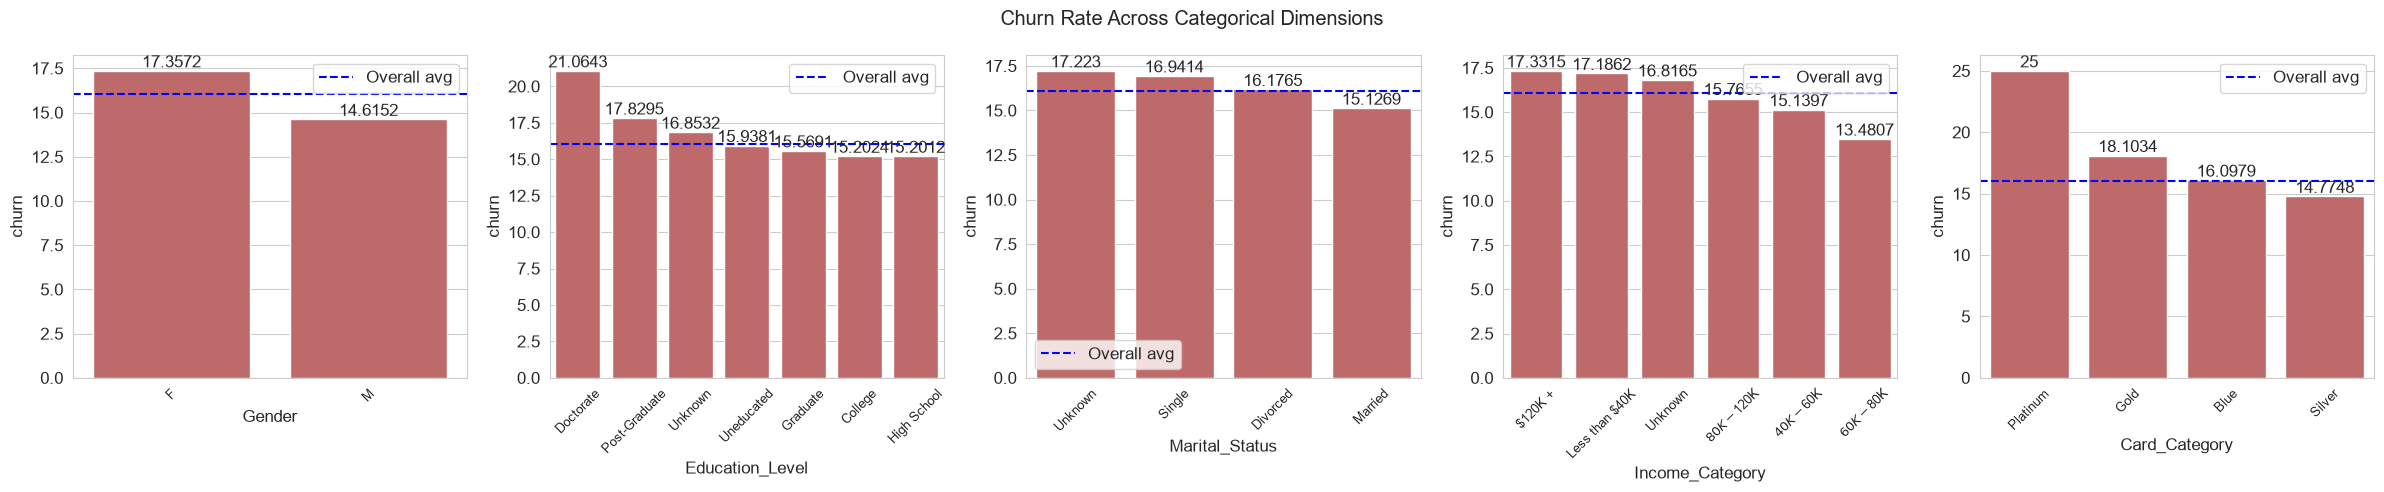

In [23]:
cat_features = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
fig, axes = plt.subplots(1,5,figsize=(24,5))
fig.set_tight_layout('tight')
fig.suptitle('Churn Rate Across Categorical Dimensions')
axes = axes.flatten()

for ax,col in zip(axes,cat_features):
    churn_rate = df.groupby(by=col)['churn'].mean()*100
    churn_rate = pd.DataFrame(churn_rate).reset_index().sort_values(by='churn',ascending=False)
    ax = sns.barplot(churn_rate,x=col,y='churn',ax=ax,color='indianred')
    for container in ax.containers:
        ax.bar_label(container)
    ax.axhline(df['churn'].mean()*100, color='blue', linestyle='--', label='Overall avg')
    ax.tick_params(axis='x',**label_kwargs)
    ax.legend()


#churn_rate = df.groupby(by='Income_Category')['churn'].mean()
#churn_rate = pd.DataFrame(churn_rate).reset_index()
#sns.barplot(data=churn_rate,x='Income_Category',y='churn')
#plt.axhline(y=churn_rate['churn'].mean())


In [24]:
# ============================================
# Cell: Verify Credit_Limit ceiling hypothesis
# ============================================
ceiling_value = df[df['Credit_Limit'] == 34516.0]
print(f"Rows with Credit_Limit == 34516.0: {len(ceiling_value)}")
print(f"\nAttrition rate within this group:")
print(ceiling_value['Attrition_Flag'].value_counts(normalize=True) * 100)

Rows with Credit_Limit == 34516.0: 508

Attrition rate within this group:
Attrition_Flag
Existing Customer   82.48
Attrited Customer   17.52
Name: proportion, dtype: float64


In [25]:
cat_features = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

print(f"{'Feature':<20} {'Chi2':>10} {'p-value':>12} {'Significant (p<0.05)':>22}")
print("-" * 66)

for col in cat_features:
    contingency = pd.crosstab(df[col], df['Attrition_Flag'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    sig = "YES" if p < 0.05 else "no"
    print(f"{col:<20} {chi2:>10.2f} {p:>12.6f} {sig:>22}")

Feature                    Chi2      p-value   Significant (p<0.05)
------------------------------------------------------------------
Gender                    13.87     0.000196                    YES
Education_Level           12.51     0.051489                     no
Marital_Status             6.06     0.108913                     no
Income_Category           12.83     0.025002                    YES
Card_Category              2.23     0.525238                     no


### Creating age segment categories


In [26]:
bins=[25, 35, 45, 55, 73]
labels=['26-35', '36-45', '46-55', '56-73']
df['Age_group'] = pd.cut(df['Customer_Age'],bins=bins,labels=labels)

print(df['Age_group'].value_counts().sort_index())
print(f"\nAny nulls after binning: {df['Age_group'].isnull().sum()}")

Age_group
26-35     919
36-45    3742
46-55    4135
56-73    1331
Name: count, dtype: int64

Any nulls after binning: 0


#### Churn rate by age group (Baseline check)

In [27]:
age_churn = df.groupby(by='Age_group', observed=True)['churn'].agg(['mean','count'])
age_churn

,mean,count
Age_group,,
26-35,0.13,919
36-45,0.16,3742
46-55,0.17,4135
56-73,0.16,1331


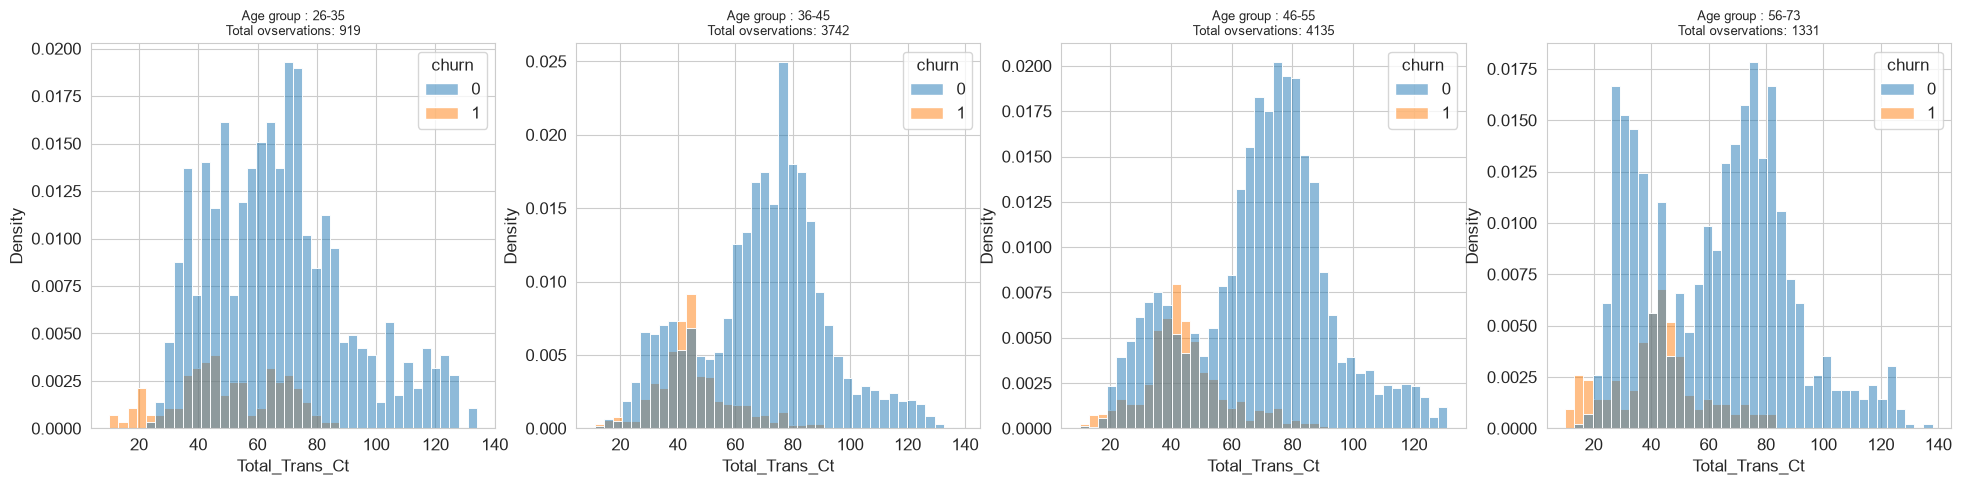

In [28]:
# ====================================================================
# Cell: Multivariate - Total_Trans_Ct vs Churn, Segmented by Age Group
# ====================================================================
fig, axes = plt.subplots(1,4,figsize = (24,5))
axes = axes.flatten()
age_groups = df['Age_group'].cat.categories


for ax,age_grp in zip(axes,age_groups):
    sns.histplot(data=df[df['Age_group'] == age_grp],x='Total_Trans_Ct',bins=40,ax=ax,hue='churn',stat='density')
    ax.set_title(f"Age group : {age_grp}\nTotal ovservations: {age_churn.loc[age_grp,'count']}",fontsize = 9)


In [29]:
# ============================================
# Cell: Correlation of Total_Trans_Ct with Churn, Per Age Segment
# ============================================
print(f"{'Age group':<12} {'Correlation w/ Churn':>22} {'N':>8}")
print("-" * 45)

for group in age_groups:
    subset = df[df['Age_group'] == group]
    corr = subset['Total_Trans_Ct'].corr(subset['churn'])
    print(f"{str(group):<12} {corr:>22.3f} {len(subset):>8}")

overall_corr = df['Total_Trans_Ct'].corr(df['churn'])
print(f"\nOverall (unsegmented) correlation: {overall_corr:.3f}")

Age group      Correlation w/ Churn        N
---------------------------------------------
26-35                        -0.254      919
36-45                        -0.396     3742
46-55                        -0.405     4135
56-73                        -0.298     1331

Overall (unsegmented) correlation: -0.371


#### Do risk factor compound ??

In [30]:
df['Trans_Ct_Level'] = pd.qcut(x=df['Total_Trans_Ct'],q=3,labels=['Low','Medium','High'],duplicates='drop')
df['Relationship_Level'] = pd.cut(
    df['Total_Relationship_Count'],
    bins=[0, 2, 6],
    labels=['Low (1-2)', 'High (3-6)']
)
compound_risk = df.groupby(['Relationship_Level', 'Trans_Ct_Level'], observed=True)['churn'].agg(['mean', 'count'])
compound_risk['mean'] = (compound_risk['mean'] * 100).round(2)
compound_risk.columns = ['Churn Rate (%)', 'Count']
print(compound_risk)

                                   Churn Rate (%)  Count
Relationship_Level Trans_Ct_Level                       
Low (1-2)          Low                      88.61    483
                   Medium                   32.21    385
                   High                      2.10   1285
High (3-6)         Low                      29.38   2975
                   Medium                    4.85   2990
                   High                      1.44   2009


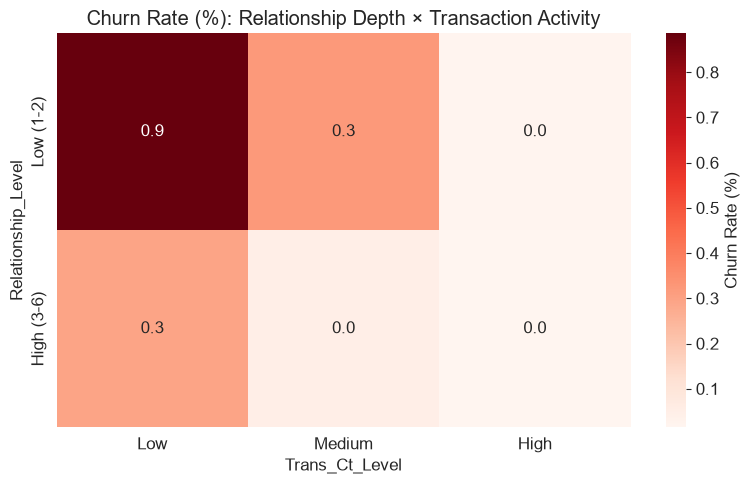

In [31]:
pivot = df.pivot_table(index='Relationship_Level',
               columns='Trans_Ct_Level',
               values='churn',
               aggfunc='mean',
               observed=True
              )
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%): Relationship Depth × Transaction Activity')
plt.tight_layout()
plt.show()

### Phase 5 : Feature Engineering

In [32]:
# df['Credit_Limit'].min() = 1438.30
df['is_min_credit_limit'] = (df['Credit_Limit'] == 1438.30).astype('int')
# Verify: count should match what we found in Phase 2 (507 customers)
print(f"Customers flagged: {df['is_min_credit_limit'].sum()}")
print(f"\nChurn rate comparison:")
print(df.groupby('is_min_credit_limit')['churn'].mean() * 100)

# Confirm shape only gained a column, row count unchanged
print(f"\nDataset shape: {df.shape}")

Customers flagged: 507

Churn rate comparison:
is_min_credit_limit
0   15.62
1   24.46
Name: churn, dtype: float64

Dataset shape: (10127, 25)


In [33]:
df.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'churn', 'Age_group', 'Trans_Ct_Level', 'Relationship_Level',
       'is_min_credit_limit'],
      dtype='str')

In [34]:
df['Avg_Trans_Value'] = df['Total_Trans_Amt']/df['Total_Trans_Ct']
print(df[['Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Trans_Value']].head())
print(f"\nAvg_Trans_Value summary:")
print(df['Avg_Trans_Value'].describe())

# Check correlation with churn - does this new ratio add signal?
print(f"\nCorrelation with churn: {df['Avg_Trans_Value'].corr(df['churn']):.3f}")

   Total_Trans_Amt  Total_Trans_Ct  Avg_Trans_Value
0             1144              42            27.24
1             1291              33            39.12
2             1887              20            94.35
3             1171              20            58.55
4              816              28            29.14

Avg_Trans_Value summary:
count   10127.00
mean       62.61
std        26.40
min        19.14
25%        47.51
50%        55.79
75%        65.48
max       190.19
Name: Avg_Trans_Value, dtype: float64

Correlation with churn: 0.016


In [35]:
# ============================================
# Decision: Avg_Trans_Value does not add value - drop it
# ============================================
df.drop(columns=['Avg_Trans_Value'], inplace=True)
print(f"Dropped. Current shape: {df.shape}")

Dropped. Current shape: (10127, 25)


In [36]:
# ============================================
# Feature 3: high_risk_segment
# ============================================

#df[['Trans_Ct_Level','Relationship_Level']].value_counts()
df['high_risk_segment'] = ((df['Trans_Ct_Level'] == 'Low') & (df['Relationship_Level'] == 'Low (1-2)')).astype(int)
# Verify: should match our multivariate table exactly - 483 flagged
print(f"Customers flagged: {df['high_risk_segment'].sum()}")

print(f"\nChurn rate comparison:")
print(df.groupby('high_risk_segment')['churn'].mean() * 100)

print(f"\nCorrelation with churn: {df['high_risk_segment'].corr(df['churn']):.3f}")

Customers flagged: 483

Churn rate comparison:
high_risk_segment
0   12.43
1   88.61
Name: churn, dtype: float64

Correlation with churn: 0.442


In [37]:
# ============================================
# Cleanup: Remove temporary EDA/investigation columns
# ============================================
cols_to_drop = ['Age_group', 'Relationship_Level', 'Trans_Ct_Level']
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped: {cols_to_drop}")
print(f"Current shape: {df.shape}")
print(f"\nCurrent columns:\n{df.columns.tolist()}")

Dropped: ['Age_group', 'Relationship_Level', 'Trans_Ct_Level']
Current shape: (10127, 23)

Current columns:
['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'churn', 'is_min_credit_limit', 'high_risk_segment']


In [38]:
df.shape
print(df.columns.tolist())
print(f"Total: {len(df.columns)}")

['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'churn', 'is_min_credit_limit', 'high_risk_segment']
Total: 23


In [39]:
# ============================================
# Feature Transformation: Log-transform skewed features
# ============================================
skewed_cols = ['Credit_Limit', 'Avg_Open_To_Buy', 'Total_Trans_Amt']

for col in skewed_cols:
    df[f'{col}_log'] = np.log1p(df[col])

# Compare skewness before vs after
print(f"{'Feature':<25} {'Skew (raw)':>12} {'Skew (log)':>12}")
print("-" * 51)
for col in skewed_cols:
    raw_skew = df[col].skew()
    log_skew = df[f'{col}_log'].skew()
    print(f"{col:<25} {raw_skew:>12.3f} {log_skew:>12.3f}")

print(f"\nShape after adding log features: {df.shape}")

Feature                     Skew (raw)   Skew (log)
---------------------------------------------------
Credit_Limit                     1.667        0.457
Avg_Open_To_Buy                  1.662       -0.095
Total_Trans_Amt                  2.041        0.263

Shape after adding log features: (10127, 26)


In [40]:
# ============================================
# Test Hypothesis B: Does "non-disclosure in general" correlate with churn?
# ============================================
df['any_unknown'] = (
    (df['Education_Level'] == 'Unknown') | 
    (df['Income_Category'] == 'Unknown') |
    (df['Marital_Status'] == 'Unknown')
).astype(int)
df.groupby(by='any_unknown')['churn'].mean()*100

any_unknown
0   15.72
1   16.87
Name: churn, dtype: float64

In [41]:
df.drop(columns=['any_unknown'], inplace=True)
print(f"Shape after cleanup: {df.shape}")

Shape after cleanup: (10127, 26)


In [42]:
# ============================================
# Cell: Define ordinal mappings explicitly
# ============================================

# Education: Unknown placed at neutral middle position, not lowest/highest
education_map = {
    'Uneducated': 0,
    'High School': 1,
    'Unknown': 2,          # neutral placeholder, not a real rank
    'College': 3,
    'Graduate': 4,
    'Post-Graduate': 5,
    'Doctorate': 6
}

# Income: same neutral treatment
income_map = {
    'Less than $40K': 0,
    'Unknown': 1,           # neutral placeholder
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5
}

df['Education_Level_encoded'] = df['Education_Level'].map(education_map)
df['Income_Category_encoded'] = df['Income_Category'].map(income_map)

# Verify no nulls introduced (would mean a category wasn't in our map)
print(df['Education_Level_encoded'].isnull().sum())
print(df['Income_Category_encoded'].isnull().sum())

print(df[['Education_Level', 'Education_Level_encoded']].drop_duplicates())
print(df[['Income_Category', 'Income_Category_encoded']].drop_duplicates())

0
0
   Education_Level  Education_Level_encoded
0      High School                        1
1         Graduate                        4
4       Uneducated                        0
6          Unknown                        2
12         College                        3
16   Post-Graduate                        5
20       Doctorate                        6
   Income_Category  Income_Category_encoded
0      $60K - $80K                        3
1   Less than $40K                        0
2     $80K - $120K                        4
5      $40K - $60K                        2
6          $120K +                        5
19         Unknown                        1


In [43]:
# ============================================
# Collapse Card_Category: Blue vs Other
# Justified by Chi-square (p=0.53, not significant) and severe rarity 
# in Silver/Gold/Platinum (671 combined vs 9,436 Blue)
# ============================================

df['Card_Category_grouped'] = df['Card_Category'].apply(lambda x: 'Blue' if x=='Blue' else 'Other')
print(df['Card_Category_grouped'].value_counts())
print(f"\nChurn rate by grouped card category:")
print(df.groupby('Card_Category_grouped')['churn'].mean() * 100)

Card_Category_grouped
Blue     9436
Other     691
Name: count, dtype: int64

Churn rate by grouped card category:
Card_Category_grouped
Blue    16.10
Other   15.63
Name: churn, dtype: float64


In [44]:
# ============================================
# One-Hot Encoding: Gender, Marital_Status, Card_Category_grouped
# ============================================
df = pd.get_dummies(
    df, 
    columns=['Gender', 'Marital_Status', 'Card_Category_grouped'], 
    drop_first=True  # avoid dummy variable trap
)

print(f"Shape after one-hot encoding: {df.shape}")
print(df.columns.tolist())


Shape after one-hot encoding: (10127, 31)
['Attrition_Flag', 'Customer_Age', 'Dependent_count', 'Education_Level', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'churn', 'is_min_credit_limit', 'high_risk_segment', 'Credit_Limit_log', 'Avg_Open_To_Buy_log', 'Total_Trans_Amt_log', 'Education_Level_encoded', 'Income_Category_encoded', 'Gender_M', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_grouped_Other']


In [45]:
# ============================================
# Final Phase 5 Cleanup: Drop columns superseded by encoded versions
# ============================================
df.drop(columns=['Education_Level', 'Income_Category', 'Card_Category'], inplace=True)

print(f"Final Phase 5 shape: {df.shape}")
print(f"\nFinal column list:")
print(df.columns.tolist())

Final Phase 5 shape: (10127, 28)

Final column list:
['Attrition_Flag', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'churn', 'is_min_credit_limit', 'high_risk_segment', 'Credit_Limit_log', 'Avg_Open_To_Buy_log', 'Total_Trans_Amt_log', 'Education_Level_encoded', 'Income_Category_encoded', 'Gender_M', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_grouped_Other']


### Phase 6 : Feature Selection

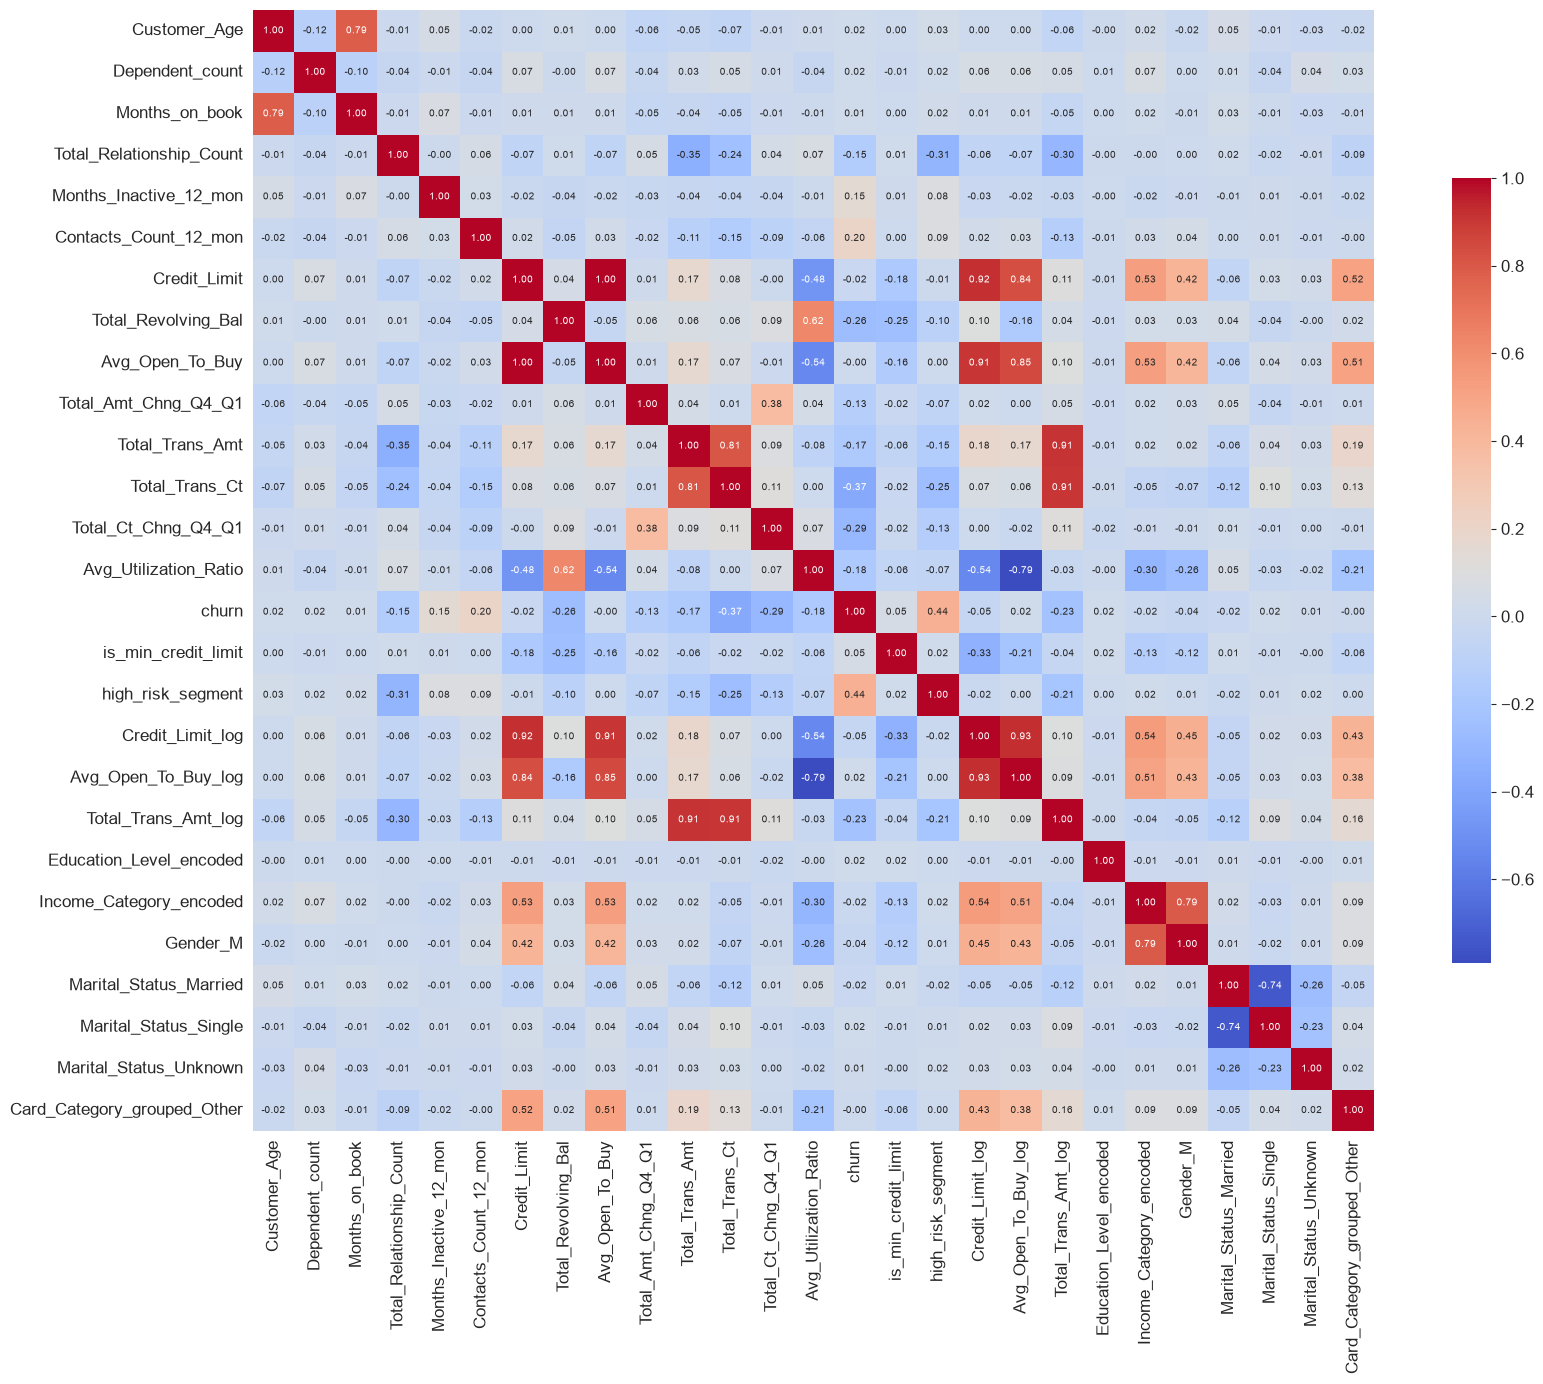

In [46]:
model_cols = df.columns.drop('Attrition_Flag').tolist()
corr_full  = df[model_cols].corr()
plt.figure(figsize=(18,14))
sns.heatmap(corr_full,annot=True,fmt='.2f',cmap='coolwarm',square=True,annot_kws={'size': 7},cbar_kws={'shrink':0.7})
plt.tight_layout()
plt.show()

In [47]:
# ============================================
# Cell: Churn correlation, ranked - full feature set
# ============================================
target_corr_full = corr_full[['churn']].drop(index='churn',axis=0)
print("All features ranked by |correlation| with churn:")
print(target_corr_full.sort_values(by='churn',ascending=False))

All features ranked by |correlation| with churn:
                             churn
high_risk_segment             0.44
Contacts_Count_12_mon         0.20
Months_Inactive_12_mon        0.15
is_min_credit_limit           0.05
Marital_Status_Single         0.02
Dependent_count               0.02
Customer_Age                  0.02
Avg_Open_To_Buy_log           0.02
Education_Level_encoded       0.02
Months_on_book                0.01
Marital_Status_Unknown        0.01
Avg_Open_To_Buy              -0.00
Card_Category_grouped_Other  -0.00
Income_Category_encoded      -0.02
Marital_Status_Married       -0.02
Credit_Limit                 -0.02
Gender_M                     -0.04
Credit_Limit_log             -0.05
Total_Amt_Chng_Q4_Q1         -0.13
Total_Relationship_Count     -0.15
Total_Trans_Amt              -0.17
Avg_Utilization_Ratio        -0.18
Total_Trans_Amt_log          -0.23
Total_Revolving_Bal          -0.26
Total_Ct_Chng_Q4_Q1          -0.29
Total_Trans_Ct               -0.37


In [48]:
# ============================================
# Cell: Flag new high multicollinearity pairs (|r| > 0.7)
# ============================================
corr_full

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,churn,is_min_credit_limit,high_risk_segment,Credit_Limit_log,Avg_Open_To_Buy_log,Total_Trans_Amt_log,Education_Level_encoded,Income_Category_encoded,Gender_M,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_grouped_Other
Customer_Age,1.00,-0.12,0.79,-0.01,0.05,-0.02,0.00,0.01,0.00,-0.06,-0.05,-0.07,-0.01,0.01,0.02,0.00,0.03,0.00,0.00,-0.06,-0.00,0.02,-0.02,0.05,-0.01,-0.03,-0.02
Dependent_count,-0.12,1.00,-0.10,-0.04,-0.01,-0.04,0.07,-0.00,0.07,-0.04,0.03,0.05,0.01,-0.04,0.02,-0.01,0.02,0.06,0.06,0.05,0.01,0.07,0.00,0.01,-0.04,0.04,0.03
Months_on_book,0.79,-0.10,1.00,-0.01,0.07,-0.01,0.01,0.01,0.01,-0.05,-0.04,-0.05,-0.01,-0.01,0.01,0.00,0.02,0.01,0.01,-0.05,0.00,0.02,-0.01,0.03,-0.01,-0.03,-0.01
Total_Relationship_Count,-0.01,-0.04,-0.01,1.00,-0.00,0.06,-0.07,0.01,-0.07,0.05,-0.35,-0.24,0.04,0.07,-0.15,0.01,-0.31,-0.06,-0.07,-0.30,-0.00,-0.00,0.00,0.02,-0.02,-0.01,-0.09
Months_Inactive_12_mon,0.05,-0.01,0.07,-0.00,1.00,0.03,-0.02,-0.04,-0.02,-0.03,-0.04,-0.04,-0.04,-0.01,0.15,0.01,0.08,-0.03,-0.02,-0.03,-0.00,-0.02,-0.01,-0.01,0.01,-0.01,-0.02
Contacts_Count_12_mon,-0.02,-0.04,-0.01,0.06,0.03,1.00,0.02,-0.05,0.03,-0.02,-0.11,-0.15,-0.09,-0.06,0.20,0.00,0.09,0.02,0.03,-0.13,-0.01,0.03,0.04,0.00,0.01,-0.01,-0.00
Credit_Limit,0.00,0.07,0.01,-0.07,-0.02,0.02,1.00,0.04,1.00,0.01,0.17,0.08,-0.00,-0.48,-0.02,-0.18,-0.01,0.92,0.84,0.11,-0.01,0.53,0.42,-0.06,0.03,0.03,0.52
Total_Revolving_Bal,0.01,-0.00,0.01,0.01,-0.04,-0.05,0.04,1.00,-0.05,0.06,0.06,0.06,0.09,0.62,-0.26,-0.25,-0.10,0.10,-0.16,0.04,-0.01,0.03,0.03,0.04,-0.04,-0.00,0.02
Avg_Open_To_Buy,0.00,0.07,0.01,-0.07,-0.02,0.03,1.00,-0.05,1.00,0.01,0.17,0.07,-0.01,-0.54,-0.00,-0.16,0.00,0.91,0.85,0.10,-0.01,0.53,0.42,-0.06,0.04,0.03,0.51
Total_Amt_Chng_Q4_Q1,-0.06,-0.04,-0.05,0.05,-0.03,-0.02,0.01,0.06,0.01,1.00,0.04,0.01,0.38,0.04,-0.13,-0.02,-0.07,0.02,0.00,0.05,-0.01,0.02,0.03,0.05,-0.04,-0.01,0.01


In [49]:
print(f'the total number of axis(rows) : {len(corr_full)}')
print(f'the total number of columns : {len(corr_full.columns)}')

high_corr_pairs = [ ]
for i in range(len(corr_full)-1):
    for j in range(i+1,len(corr_full.columns)):
        if (i!=j) & (corr_full.iloc[i,j] > 0.7):
            pair = (corr_full.index[i],corr_full.columns[j],corr_full.iloc[i,j])
            high_corr_pairs.append(pair)
high_corr_pairs

high_corr_df = pd.DataFrame(high_corr_pairs,columns=['Variable1','Variable2','Correlation'])
high_corr_df

the total number of axis(rows) : 27
the total number of columns : 27


,Variable1,Variable2,Correlation
0,Customer_Age,Months_on_book,0.79
1,Credit_Limit,Avg_Open_To_Buy,1.00
2,Credit_Limit,Credit_Limit_log,0.92
3,Credit_Limit,Avg_Open_To_Buy_log,0.84
4,Avg_Open_To_Buy,Credit_Limit_log,0.91
5,Avg_Open_To_Buy,Avg_Open_To_Buy_log,0.85
6,Total_Trans_Amt,Total_Trans_Ct,0.81
7,Total_Trans_Amt,Total_Trans_Amt_log,0.91
8,Total_Trans_Ct,Total_Trans_Amt_log,0.91
9,Credit_Limit_log,Avg_Open_To_Buy_log,0.93


In [50]:
# ============================================
# Verify: is this real, or an artifact of our own encoding?
# ============================================

# Cross-tab using RAW Income_Category text (not our encoded version) against raw Gender
# Reload isn't needed if you still have Attrition_Flag/original cols - but Income_Category 
# and Gender (raw) were dropped. Use the encoded/dummy versions we still have:
print(pd.crosstab(df['Income_Category_encoded'], df['Gender_M']))

# Also check as row percentages, to see the split WITHIN each income band clearly
print("\nAs % within each income category:")
print(pd.crosstab(df['Income_Category_encoded'], df['Gender_M'], normalize='index') * 100)

Gender_M                 False  True 
Income_Category_encoded              
0                         3284    277
1                         1060     52
2                         1014    776
3                            0   1402
4                            0   1535
5                            0    727

As % within each income category:
Gender_M                 False  True 
Income_Category_encoded              
0                        92.22   7.78
1                        95.32   4.68
2                        56.65  43.35
3                         0.00 100.00
4                         0.00 100.00
5                         0.00 100.00


In [51]:
# ============================================
# Document: Income/Gender data artifact (for fairness audit + limitations section)
# ============================================
finding_note = """
DATA LIMITATION — Income_Category / Gender Confound (identified Phase 6)

Income_Category_encoded and Gender_M show near-perfect structural separation, 
not merely correlation (r=0.79):
  - Income bands 3, 4, 5 (\$60K-\$80K, \$80K-\$120K, \$120K+): 100% male (n=1402, 1535, 727)
  - Income bands 0, 1 (Less than \$40K, Unknown): 92-95% female
  - Only band 2 (\$40K-\$60K) shows meaningful mixing (57% F / 43% M)

This is almost certainly a data collection artifact in the source dataset, not a 
genuine population-level income distribution. Possible causes: household income 
attributed to a male primary account holder, or an artifact of how this dataset 
was compiled/released.

IMPLICATION: Excluding Gender from the model does NOT remove gender-based signal 
if Income_Category is retained, since income functions as a near-deterministic 
gender proxy above the $60K threshold.

REQUIRED ACTION (Phase 13): Fairness audit must test whether false-negative-rate 
gap between genders persists after controlling for Income_Category, not just 
report an unconditional subgroup gap.
"""
print(finding_note)


DATA LIMITATION — Income_Category / Gender Confound (identified Phase 6)

Income_Category_encoded and Gender_M show near-perfect structural separation, 
not merely correlation (r=0.79):
  - Income bands 3, 4, 5 (\$60K-\$80K, \$80K-\$120K, \$120K+): 100% male (n=1402, 1535, 727)
  - Income bands 0, 1 (Less than \$40K, Unknown): 92-95% female
  - Only band 2 (\$40K-\$60K) shows meaningful mixing (57% F / 43% M)

This is almost certainly a data collection artifact in the source dataset, not a 
genuine population-level income distribution. Possible causes: household income 
attributed to a male primary account holder, or an artifact of how this dataset 
was compiled/released.

IMPLICATION: Excluding Gender from the model does NOT remove gender-based signal 
if Income_Category is retained, since income functions as a near-deterministic 
gender proxy above the $60K threshold.

REQUIRED ACTION (Phase 13): Fairness audit must test whether false-negative-rate 
gap between genders persists afte

<>:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\uSer\AppData\Local\Temp\ipykernel_23604\1139379507.py:9: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  - Income bands 3, 4, 5 (\$60K-\$80K, \$80K-\$120K, \$120K+): 100% male (n=1402, 1535, 727)


In [52]:
# ============================================
# Cell: Drop confirmed redundant columns
# ============================================
df.drop(columns=['Avg_Open_To_Buy', 'Avg_Open_To_Buy_log'], inplace=True)

print(f"Shape after cleanup: {df.shape}")
print(df.columns.tolist())
print(f"Shape after dropping Avg_Open_To_Buy (raw + log): {df.shape}")
print(df.columns.tolist())

Shape after cleanup: (10127, 26)
['Attrition_Flag', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'churn', 'is_min_credit_limit', 'high_risk_segment', 'Credit_Limit_log', 'Total_Trans_Amt_log', 'Education_Level_encoded', 'Income_Category_encoded', 'Gender_M', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_grouped_Other']
Shape after dropping Avg_Open_To_Buy (raw + log): (10127, 26)
['Attrition_Flag', 'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'churn', 'is_min_credit_limit', 'high

In [53]:
bool_cols = df.select_dtypes(include='bool').columns.tolist()
print(f'Boolean Columns found: {bool_cols}')
df[bool_cols] = df[bool_cols].astype('int')
df.info()

Boolean Columns found: ['Gender_M', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_grouped_Other']
<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Attrition_Flag               10127 non-null  str    
 1   Customer_Age                 10127 non-null  int64  
 2   Dependent_count              10127 non-null  int64  
 3   Months_on_book               10127 non-null  int64  
 4   Total_Relationship_Count     10127 non-null  int64  
 5   Months_Inactive_12_mon       10127 non-null  int64  
 6   Contacts_Count_12_mon        10127 non-null  int64  
 7   Credit_Limit                 10127 non-null  float64
 8   Total_Revolving_Bal          10127 non-null  int64  
 9   Total_Amt_Chng_Q4_Q1         10127 non-null  float64
 10  Total_Trans_Amt              10127 non-null  int64  
 11 

##### Model Based Feature Importance (Baseline: Random Forests)

In [54]:
# Confirm current feature set first
X = df.drop(columns=['Attrition_Flag', 'churn'])
y = df['churn']
print(f"Confirmed feature count: {X.shape[1]}")
print(f"Avg_Open_To_Buy present: {'Avg_Open_To_Buy' in X.columns}")

# Correlation, computed fresh on the SAME X
corr_with_churn = df[X.columns.tolist() + ['churn']].corr()['churn'].drop('churn')



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
rf_baseline = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

importance = pd.Series(rf_baseline.feature_importances_, index=X.columns)

# Combine cleanly - both built from the identical feature set, no merge needed
comparison = pd.DataFrame({
    'Correlation': corr_with_churn,
    'Feature_Importance': importance
})
comparison['Corr_rank'] = comparison['Correlation'].abs().rank(ascending=False)
comparison['FI_rank'] = comparison['Feature_Importance'].rank(ascending=False)
comparison['Avg_rank'] = (comparison['Corr_rank'] + comparison['FI_rank']) / 2

comparison = comparison.sort_values('Avg_rank')
print(comparison.to_string())

Confirmed feature count: 24
Avg_Open_To_Buy present: False
                             Correlation  Feature_Importance  Corr_rank  FI_rank  Avg_rank
Total_Trans_Ct                     -0.37                0.13       2.00     1.00      1.50
Total_Ct_Chng_Q4_Q1                -0.29                0.09       3.00     4.00      3.50
high_risk_segment                   0.44                0.08       1.00     6.00      3.50
Total_Trans_Amt_log                -0.23                0.12       5.00     2.00      3.50
Total_Revolving_Bal                -0.26                0.09       4.00     5.00      4.50
Total_Trans_Amt                    -0.17                0.12       8.00     3.00      5.50
Avg_Utilization_Ratio              -0.18                0.06       7.00     7.00      7.00
Contacts_Count_12_mon               0.20                0.02       6.00    13.00      9.50
Total_Amt_Chng_Q4_Q1               -0.13                0.06      11.00     8.00      9.50
Total_Relationship_Count       

### Phase 7 : Data Pre-Processing

In [55]:
# ============================================
# Cell: Train/Test Split (before any preprocessing)
# ============================================
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Attrition_Flag', 'churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"\nTrain churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate: {y_test.mean()*100:.2f}%")

Train shape: (8101, 24)
Test shape: (2026, 24)

Train churn rate: 16.07%
Test churn rate: 16.04%


In [56]:
# ============================================
# Cell: Feature Groups for Preprocessing
# ============================================

# Continuous features needing scaling - raw versions for tree models
numeric_features_raw = [
    'Customer_Age', 'Dependent_count', 'Months_on_book', 
    'Total_Relationship_Count', 'Months_Inactive_12_mon', 
    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
    'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

# Already-binary / already-encoded - no further transformation needed
passthrough_features = [
    'is_min_credit_limit', 'high_risk_segment', 'Education_Level_encoded',
    'Income_Category_encoded', 'Gender_M', 'Marital_Status_Married',
    'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_grouped_Other'
]

# Log-transformed versions - alternative representation for linear models
log_features = ['Credit_Limit_log', 'Total_Trans_Amt_log']

print(f"Raw numeric: {len(numeric_features_raw)}")
print(f"Passthrough (already 0/1 or ordinal): {len(passthrough_features)}")
print(f"Log versions: {len(log_features)}")
print(f"Total: {len(numeric_features_raw) + len(passthrough_features) + len(log_features)}")

Raw numeric: 13
Passthrough (already 0/1 or ordinal): 9
Log versions: 2
Total: 24


In [57]:
# ============================================
# Cell: Pipeline A - For Tree-Based Models (raw features)
# ============================================
tree_features = numeric_features_raw + passthrough_features
preprocessor_tree = ColumnTransformer(
    transformers=[('num','passthrough',numeric_features_raw),
                  ('bin','passthrough',passthrough_features)])
preprocessor_tree

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [58]:
# ============================================
# Cell: Pipeline B - For Linear/Distance-Based Models (scaled + log features)
# ============================================
numeric_for_linear = [f for f in numeric_features_raw if f not in ['Credit_Limit','Total_Trans_Amt']]
linear_features = numeric_for_linear + log_features + passthrough_features
preprocessor_linear = ColumnTransformer(transformers=[('scaled_num',StandardScaler(),numeric_for_linear+log_features),
                                                      ('bin','passthrough',passthrough_features)])
preprocessor_linear

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaled_num', ...), ('bin', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [59]:
# ============================================
# Cell: Fit on TRAIN only, transform both train and test
# ============================================

# Tree pipeline
X_train_tree = preprocessor_tree.fit_transform(X_train[tree_features])
X_test_tree = preprocessor_tree.transform(X_test[tree_features])

# Linear pipeline
X_train_linear = preprocessor_linear.fit_transform(X_train[linear_features])
X_test_linear = preprocessor_linear.transform(X_test[linear_features])

print(f"Tree - Train: {X_train_tree.shape}, Test: {X_test_tree.shape}")
print(f"Linear - Train: {X_train_linear.shape}, Test: {X_test_linear.shape}")


Tree - Train: (8101, 22), Test: (2026, 22)
Linear - Train: (8101, 22), Test: (2026, 22)


In [60]:
scaled_cols = numeric_for_linear + log_features
X_train_linear_df = pd.DataFrame(X_train_linear,columns=linear_features)
X_test_linear_df = pd.DataFrame(X_test_linear,columns=linear_features)

print("TRAIN set - scaled features (should be mean≈0, std≈1):")
print(X_train_linear_df[scaled_cols].describe().loc[['mean','std'],:])
print("\nTEST set - scaled features (should NOT be exactly mean=0, std=1):")
print(X_test_linear_df[scaled_cols].describe().loc[['mean','std'],:])


TRAIN set - scaled features (should be mean≈0, std≈1):
      Customer_Age  Dependent_count  Months_on_book  Total_Relationship_Count  \
mean         -0.00             0.00            0.00                      0.00   
std           1.00             1.00            1.00                      1.00   

      Months_Inactive_12_mon  Contacts_Count_12_mon  Total_Revolving_Bal  \
mean                    0.00                   0.00                 0.00   
std                     1.00                   1.00                 1.00   

      Total_Amt_Chng_Q4_Q1  Total_Trans_Ct  Total_Ct_Chng_Q4_Q1  \
mean                 -0.00           -0.00                -0.00   
std                   1.00            1.00                 1.00   

      Avg_Utilization_Ratio  Credit_Limit_log  Total_Trans_Amt_log  
mean                   0.00              0.00                 0.00  
std                    1.00              1.00                 1.00  

TEST set - scaled features (should NOT be exactly mean=0, std=

In [61]:
# ============================================
# Cell: Reassemble labeled DataFrames for both pipelines
# ============================================

# Tree pipeline - column order matches: numeric_features_raw + passthrough_features
X_train_tree_df = pd.DataFrame(X_train_tree, columns=numeric_features_raw + passthrough_features, index=X_train.index)
X_test_tree_df = pd.DataFrame(X_test_tree, columns=numeric_features_raw + passthrough_features, index=X_test.index)

# Linear pipeline - column order matches: (numeric_for_linear + log_features) + passthrough_features
X_train_linear_df = pd.DataFrame(X_train_linear, columns=numeric_for_linear + log_features + passthrough_features, index=X_train.index)
X_test_linear_df = pd.DataFrame(X_test_linear, columns=numeric_for_linear + log_features + passthrough_features, index=X_test.index)

print("Tree pipeline sample:")
print(X_train_tree_df.head(3))
print(f"\nLinear pipeline sample:")
print(X_train_linear_df.head(3))

Tree pipeline sample:
      Customer_Age  Dependent_count  Months_on_book  Total_Relationship_Count  \
2856         36.00             0.00           24.00                      4.00   
6515         44.00             3.00           36.00                      5.00   
7141         46.00             2.00           30.00                      6.00   

      Months_Inactive_12_mon  Contacts_Count_12_mon  Credit_Limit  \
2856                    3.00                   2.00       2570.00   
6515                    2.00                   3.00      25276.00   
7141                    3.00                   1.00      11670.00   

      Total_Revolving_Bal  Total_Amt_Chng_Q4_Q1  Total_Trans_Amt  \
2856              2230.00                  0.69          1755.00   
6515                 0.00                  0.85          2282.00   
7141               915.00                  0.89          4277.00   

      Total_Trans_Ct  Total_Ct_Chng_Q4_Q1  Avg_Utilization_Ratio  \
2856           42.00               

### Phase 8 : Modelling

In [62]:
# ============================================
# Cell: Baseline Logistic Regression
# ============================================
log_reg = LogisticRegression(random_state=42,class_weight=None,max_iter=1000)
log_reg.fit(X_train_linear,y_train)

y_pred = log_reg.predict(X_test_linear_df)
y_pred_proba = log_reg.predict_proba(X_test_linear_df)[:,1]

print("=" * 60)
print("LOGISTIC REGRESSION - BASELINE RESULTS")
print("=" * 60)

print(classification_report(y_test,y_pred,target_names=['Existing','Attrited']))

LOGISTIC REGRESSION - BASELINE RESULTS
              precision    recall  f1-score   support

    Existing       0.93      0.97      0.95      1701
    Attrited       0.80      0.59      0.68       325

    accuracy                           0.91      2026
   macro avg       0.87      0.78      0.82      2026
weighted avg       0.91      0.91      0.91      2026



d:\Data Projects\End_to_End_ML\my_env\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
d:\Data Projects\End_to_End_ML\my_env\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


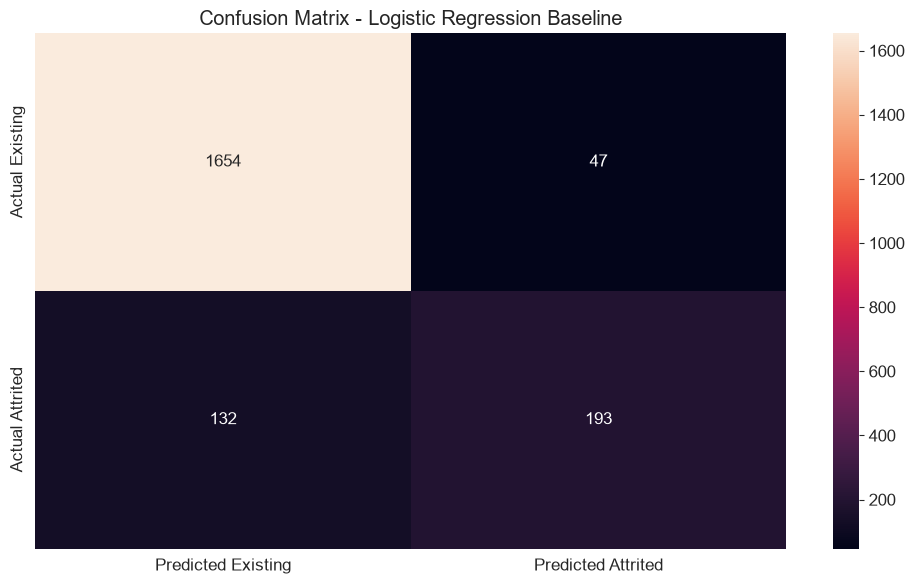

True Negatives (correctly kept as Existing): 1654
False Positives (wrongly flagged as Attrited): 47
False Negatives (MISSED churners): 132
True Positives (correctly caught churners): 193


In [63]:
# ============================================
# Cell: Confusion Matrix - Visual
# ============================================
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d', 
            xticklabels=['Predicted Existing', 'Predicted Attrited'],
            yticklabels=['Actual Existing', 'Actual Attrited'])
plt.title('Confusion Matrix - Logistic Regression Baseline')
plt.tight_layout()
plt.show()


tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly kept as Existing): {tn}")
print(f"False Positives (wrongly flagged as Attrited): {fp}")
print(f"False Negatives (MISSED churners): {fn}")
print(f"True Positives (correctly caught churners): {tp}")

In [64]:
results = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
}
results
for metric,value in results.items():
    marker = " <- Primary" if metric in ['Recall','F1-Score'] else  ""
    print(f"{metric:<12}:{value:.4f}{marker}")

Accuracy    :0.9116
Precision   :0.8042
Recall      :0.5938 <- Primary
F1-Score    :0.6832 <- Primary
ROC-AUC     :0.9354


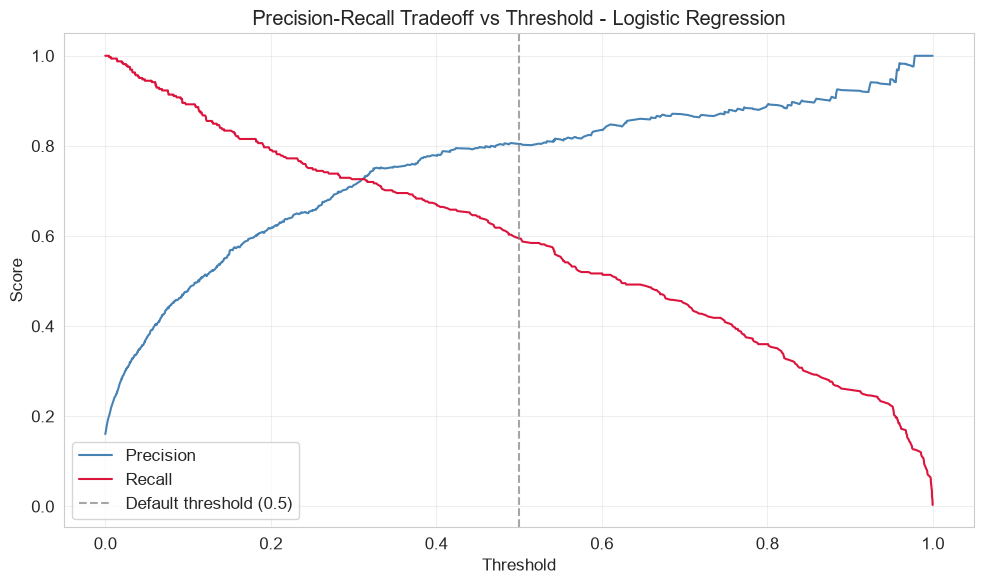

In [65]:

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='crimson')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff vs Threshold - Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
for t in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2]:
    y_pred_t = (y_pred_proba >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Threshold {t:.2f}  |  Precision: {p:.4f}  Recall: {r:.4f}  F1: {f1:.4f}")

Threshold 0.50  |  Precision: 0.8042  Recall: 0.5938  F1: 0.6832
Threshold 0.40  |  Precision: 0.7778  Recall: 0.6677  F1: 0.7185
Threshold 0.35  |  Precision: 0.7533  Recall: 0.6954  F1: 0.7232
Threshold 0.30  |  Precision: 0.7130  Recall: 0.7262  F1: 0.7195
Threshold 0.25  |  Precision: 0.6559  Recall: 0.7508  F1: 0.7001
Threshold 0.20  |  Precision: 0.6178  Recall: 0.7908  F1: 0.6937


In [67]:
# ============================================
# Cell: Record baseline at F1-optimal threshold for fair model comparison
# ============================================
optimal_threshold = 0.35
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

baseline_results = {
    'Model': 'Logistic Regression (baseline)',
    'Threshold': optimal_threshold,
    'Accuracy': accuracy_score(y_test, y_pred_optimal),
    'Precision': precision_score(y_test, y_pred_optimal),
    'Recall': recall_score(y_test, y_pred_optimal),
    'F1-Score': f1_score(y_test, y_pred_optimal),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)  # threshold-independent, unchanged
}

print(pd.DataFrame([baseline_results]).to_string(index=False))

                         Model  Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression (baseline)       0.35      0.91       0.75    0.70      0.72     0.94


In [68]:
# ============================================
# Cell: Reusable evaluation function - ensures every model gets the SAME fair treatment
# ============================================
def evaluate_model(model_name,y_true,y_pred_proba,threshold_to_test = None):
    if threshold_to_test is None:
        threshold_to_test = np.arange(0.10,0.55,0.05)

    best_f1 = -1
    best_threshold = 0.5

    for t in threshold_to_test:
        y_pred_optimal = (y_pred_proba >= t).astype(int)
        f1 = f1_score(y_true,y_pred_optimal)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    y_pred_final = (y_pred_proba >= best_threshold).astype(int)

    return {
        'Model': model_name,
        'Threshold': round(best_threshold, 2),
        'Accuracy': round(accuracy_score(y_true, y_pred_final), 4),
        'Precision': round(precision_score(y_true, y_pred_final), 4),
        'Recall': round(recall_score(y_true, y_pred_final), 4),
        'F1-Score': round(f1_score(y_true, y_pred_final), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_pred_proba), 4)
    }
    

In [69]:
### checking the function with our logistic regression

evaluate_model('logistic_regression_baseline',y_test,y_pred_proba,threshold_to_test=None)

{'Model': 'logistic_regression_baseline',
 'Threshold': np.float64(0.35),
 'Accuracy': 0.9146,
 'Precision': 0.7533,
 'Recall': 0.6954,
 'F1-Score': 0.7232,
 'ROC-AUC': 0.9354}

In [70]:
# ============================================
# Cell: Model comparison tracker - reusable across all models
# ============================================
model_comparison = pd.DataFrame([baseline_results])
model_comparison

,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (baseline),0.35,0.91,0.75,0.70,0.72,0.94


In [71]:
# ============================================
# Cell: Random Forest - Model 2
# ============================================
rf_model = RandomForestClassifier(n_estimators=300,max_depth = None,random_state=42,n_jobs=-1)
rf_model.fit(X_train_tree_df,y_train)
rf_pred_proba = rf_model.predict_proba(X_test_tree_df)[:,1]
rf_results = evaluate_model('Random forest',y_test,rf_pred_proba)
print(rf_results)

model_comparison = pd.concat([model_comparison,pd.DataFrame([rf_results])],ignore_index=True)
model_comparison



{'Model': 'Random forest', 'Threshold': np.float64(0.3), 'Accuracy': 0.9571, 'Precision': 0.8306, 'Recall': 0.92, 'F1-Score': 0.873, 'ROC-AUC': 0.9854}


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (baseline),0.35,0.91,0.75,0.70,0.72,0.94
1,Random forest,0.30,0.96,0.83,0.92,0.87,0.99


In [72]:
# ============================================
# Cell: Check for overfitting - train vs test performance
# ============================================
rf_train_proba = rf_model.predict_proba(X_train_tree_df)[:,1]
train_check = evaluate_model('Random Forest (train)',y_train,rf_train_proba)
print(train_check)

{'Model': 'Random Forest (train)', 'Threshold': np.float64(0.4), 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1-Score': 1.0, 'ROC-AUC': 1.0}


In [73]:
# ============================================
# Cell: 5-Fold Cross-Validation - Random Forest (unconstrained)
# ============================================
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_f1 = cross_val_score(rf_model,X_train_tree_df,y_train,cv=skf,scoring='f1',n_jobs=-1)
cv_recall = cross_val_score(rf_model, X_train_tree_df, y_train, cv=skf, scoring='recall', n_jobs=-1)

print(f"F1 across 5 folds: {cv_f1.round(4)}")
print(f"Mean F1: {cv_f1.mean():.4f}  (+/- {cv_f1.std():.4f})")
print(f"\nRecall across 5 folds: {cv_recall.round(4)}")
print(f"Mean Recall: {cv_recall.mean():.4f}  (+/- {cv_recall.std():.4f})")


F1 across 5 folds: [0.8742 0.8434 0.8512 0.8889 0.8083]
Mean F1: 0.8532  (+/- 0.0277)

Recall across 5 folds: [0.8123 0.7769 0.7923 0.8462 0.7433]
Mean Recall: 0.7942  (+/- 0.0344)


In [74]:
# ============================================
# Cell: Regularized Random Forest - constrain tree growth
# ============================================
rf_regularized = RandomForestClassifier(n_estimators=300,
                                        max_depth=10,
                                        min_samples_leaf= 5,
                                        random_state= 42,
                                        n_jobs= -1)
rf_regularized.fit(X_train_tree_df,y_train)

# Check train performance now
rf_reg_train_proba = rf_regularized.predict_proba(X_train_tree_df)[:, 1]
rf_reg_train_check = evaluate_model('Random Forest (regularized) - TRAIN', y_train, rf_reg_train_proba)
print(rf_reg_train_check)

# Check test performance
rf_reg_test_proba = rf_regularized.predict_proba(X_test_tree_df)[:, 1]
rf_reg_test_check = evaluate_model('Random Forest (regularized) - TEST', y_test, rf_reg_test_proba)
print(rf_reg_test_check)

{'Model': 'Random Forest (regularized) - TRAIN', 'Threshold': np.float64(0.35), 'Accuracy': 0.9744, 'Precision': 0.9005, 'Recall': 0.9455, 'F1-Score': 0.9224, 'ROC-AUC': 0.9956}
{'Model': 'Random Forest (regularized) - TEST', 'Threshold': np.float64(0.3), 'Accuracy': 0.9457, 'Precision': 0.8045, 'Recall': 0.8738, 'F1-Score': 0.8378, 'ROC-AUC': 0.9799}


In [75]:
# ============================================
# Cell: Update comparison table with regularized Random Forest
# ============================================
rf_reg_final = evaluate_model('Random Forest', y_test, rf_reg_test_proba)

# Replace the earlier (unconstrained, overfit) Random Forest entry
model_comparison = model_comparison[model_comparison['Model'] != 'Random forest']
model_comparison = pd.concat([model_comparison, pd.DataFrame([rf_reg_final])], ignore_index=True)
print(model_comparison.to_string(index=False))

                         Model  Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression (baseline)       0.35      0.91       0.75    0.70      0.72     0.94
                 Random Forest       0.30      0.95       0.80    0.87      0.84     0.98


In [76]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,              # shallower than RF default - XGBoost trees are meant to be weak learners
    learning_rate=0.1,        # controls how much each tree corrects the previous ones
    subsample=0.8,            # each tree sees 80% of rows - adds randomness, reduces overfitting
    colsample_bytree=0.8,     # each tree sees 80% of features - same purpose
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_tree_df, y_train)

xgb_pred_proba = xgb_model.predict_proba(X_test_tree_df)[:, 1]

xgb_results = evaluate_model('XGBoost', y_test, xgb_pred_proba)
print(xgb_results)

model_comparison = pd.concat([model_comparison, pd.DataFrame([xgb_results])], ignore_index=True)
print(model_comparison.to_string(index=False))

{'Model': 'XGBoost', 'Threshold': np.float64(0.4), 'Accuracy': 0.9748, 'Precision': 0.9507, 'Recall': 0.8892, 'F1-Score': 0.9189, 'ROC-AUC': 0.9931}
                         Model  Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression (baseline)       0.35      0.91       0.75    0.70      0.72     0.94
                 Random Forest       0.30      0.95       0.80    0.87      0.84     0.98
                       XGBoost       0.40      0.97       0.95    0.89      0.92     0.99


In [77]:
# ============================================
# Cell: XGBoost - Train vs Test check (proactive, learned from RF experience)
# ============================================
xgb_train_proba = xgb_model.predict_proba(X_train_tree_df)[:, 1]
xgb_train_check = evaluate_model('XGBoost - TRAIN', y_train, xgb_train_proba)

print("TRAIN:", xgb_train_check)
print("TEST: ", xgb_results)

TRAIN: {'Model': 'XGBoost - TRAIN', 'Threshold': np.float64(0.4), 'Accuracy': 0.9974, 'Precision': 0.9893, 'Recall': 0.9946, 'F1-Score': 0.992, 'ROC-AUC': 0.9999}
TEST:  {'Model': 'XGBoost', 'Threshold': np.float64(0.4), 'Accuracy': 0.9748, 'Precision': 0.9507, 'Recall': 0.8892, 'F1-Score': 0.9189, 'ROC-AUC': 0.9931}


In [78]:
# ============================================
# Cell: 5-Fold Cross-Validation - XGBoost
# ============================================
cv_f1_xgb = cross_val_score(xgb_model, X_train_tree_df, y_train, cv=skf, scoring='f1', n_jobs=-1)
cv_recall_xgb = cross_val_score(xgb_model, X_train_tree_df, y_train, cv=skf, scoring='recall', n_jobs=-1)

print(f"F1 across 5 folds: {cv_f1_xgb.round(4)}")
print(f"Mean F1: {cv_f1_xgb.mean():.4f}  (+/- {cv_f1_xgb.std():.4f})")
print(f"\nRecall across 5 folds: {cv_recall_xgb.round(4)}")
print(f"Mean Recall: {cv_recall_xgb.mean():.4f}  (+/- {cv_recall_xgb.std():.4f})")

F1 across 5 folds: [0.9153 0.9203 0.9055 0.9198 0.9045]
Mean F1: 0.9131  (+/- 0.0068)

Recall across 5 folds: [0.8697 0.8885 0.8846 0.9038 0.8889]
Mean Recall: 0.8871  (+/- 0.0109)


In [79]:
# ============================================
# Cell: KNN - Model 4
# ============================================
knn_model = KNeighborsClassifier(n_neighbors=15,n_jobs=-1)
knn_model.fit(X_train_linear_df,y_train)

knn_pred_proba = knn_model.predict_proba(X_test_linear_df)[:,1]

knn_results = evaluate_model('KNN',y_test,knn_pred_proba)
print(knn_results)

pd.concat([model_comparison,pd.DataFrame([knn_results])],ignore_index=True)

{'Model': 'KNN', 'Threshold': np.float64(0.2), 'Accuracy': 0.8959, 'Precision': 0.6532, 'Recall': 0.7477, 'F1-Score': 0.6973, 'ROC-AUC': 0.9188}


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (baseline),0.35,0.91,0.75,0.70,0.72,0.94
1,Random Forest,0.30,0.95,0.80,0.87,0.84,0.98
2,XGBoost,0.40,0.97,0.95,0.89,0.92,0.99
3,KNN,0.20,0.90,0.65,0.75,0.70,0.92


In [80]:
# ============================================
# Cell: KNN - Cross-validation check
# ============================================
cv_f1_knn = cross_val_score(knn_model,X_train_linear_df,y_train,cv=skf,scoring='f1',n_jobs=-1)
print(f"F1 across 5 folds: {cv_f1_knn.round(4)}")
print(f"Mean F1: {cv_f1_knn.mean():.4f}  (+/- {cv_f1_knn.std():.4f})")

F1 across 5 folds: [0.6111 0.649  0.6247 0.6571 0.629 ]
Mean F1: 0.6342  (+/- 0.0167)


In [81]:
cv_f1_logistic = cross_val_score(log_reg,X_train_linear_df,y_train,cv=skf,scoring='f1',n_jobs=-1)
print(f"F1 across 5 folds: {cv_f1_logistic.round(4)}")
print(f"Mean F1: {cv_f1_logistic.mean():.4f}  (+/- {cv_f1_logistic.std():.4f})")

F1 across 5 folds: [0.7171 0.7222 0.6989 0.7572 0.7226]
Mean F1: 0.7236  (+/- 0.0189)


### Phase 9 : Model Validation

In [82]:
def rigorous_cv(model,X,y,cv):
    folds = []
    for fold,(train_idx,val_idx) in enumerate(cv.split(X,y)):
        X_fold_train, X_fold_val = X.iloc[train_idx] , X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx] ,  y.iloc[val_idx]
        model.fit(X_fold_train,y_fold_train)
        prob_prediction = model.predict_proba(X_fold_val)[:,1]
        prediction = evaluate_model(f'(fold:{fold})',y_fold_val,prob_prediction,threshold_to_test=None)
        folds.append(prediction)
    return (pd.DataFrame(folds))

In [83]:
# ============================================
# Cell: Run rigorous CV for both finalists
# ============================================

print("=" * 70)
print("XGBoost - Rigorous Per-Fold Cross-Validation")
print("=" * 70)
xgb_cv_results = rigorous_cv(xgb_model,X_train_tree_df,y_train,skf)
print(xgb_cv_results.to_string(index=False))
print(f"Mean F1: {xgb_cv_results['F1-Score'].mean():.4f} (+/-{xgb_cv_results['F1-Score'].std():.4f})")
print(f"Mean Recall: {xgb_cv_results['Recall'].mean():.4f} (+/-{xgb_cv_results['Recall'].std():.4f})")
print(f"Threshold range choosen : {xgb_cv_results['Threshold'].min()} to {xgb_cv_results['Threshold'].max()}")


XGBoost - Rigorous Per-Fold Cross-Validation
   Model  Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
(fold:0)       0.35      0.98       0.94    0.92      0.93     1.00
(fold:1)       0.50      0.98       0.95    0.89      0.92     0.99
(fold:2)       0.50      0.97       0.93    0.88      0.91     0.99
(fold:3)       0.40      0.98       0.92    0.94      0.93     1.00
(fold:4)       0.50      0.97       0.92    0.89      0.90     0.99
Mean F1: 0.9187 (+/-0.0134)
Mean Recall: 0.9040 (+/-0.0238)
Threshold range choosen : 0.35 to 0.5


In [84]:
print("=" * 70)
print("Random Forest - Rigorous Per-Fold Cross-Validation")
print("=" * 70)
rf_cv_results = rigorous_cv(rf_regularized, X_train_tree_df, y_train, skf)
print(rf_cv_results.to_string(index=False))
print(f"\nMean F1: {rf_cv_results['F1-Score'].mean():.4f} (+/- {rf_cv_results['F1-Score'].std():.4f})")
print(f"Mean Recall: {rf_cv_results['Recall'].mean():.4f} (+/- {rf_cv_results['Recall'].std():.4f})")
print(f"Threshold range chosen across folds: {rf_cv_results['Threshold'].min()} - {rf_cv_results['Threshold'].max()}")

Random Forest - Rigorous Per-Fold Cross-Validation
   Model  Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
(fold:0)       0.25      0.96       0.83    0.95      0.89     0.99
(fold:1)       0.30      0.95       0.83    0.91      0.86     0.98
(fold:2)       0.30      0.95       0.80    0.91      0.85     0.98
(fold:3)       0.35      0.96       0.85    0.92      0.89     0.99
(fold:4)       0.30      0.94       0.80    0.87      0.83     0.98

Mean F1: 0.8648 (+/- 0.0235)
Mean Recall: 0.9117 (+/- 0.0279)
Threshold range chosen across folds: 0.25 - 0.35


In [85]:
param_distributions = {
    'max_depth': randint(3, 9),              # integers 3 through 8
    'learning_rate': uniform(0.01, 0.29),    # continuous between 0.01 and 0.30
    'n_estimators': randint(100, 501),       # integers 100 through 500
    'subsample': uniform(0.6, 0.4),          # continuous between 0.6 and 1.0
    'colsample_bytree': uniform(0.6, 0.4),   # continuous between 0.6 and 1.0
    'min_child_weight': randint(1, 11),      # integers 1 through 10
}
print("Search spaced defined:")
for param, dist in param_distributions.items():
    print(f"{param}:{dist}")


Search spaced defined:
max_depth:<scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000264B9FB0830>
learning_rate:<scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000264B9FB0050>
n_estimators:<scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000264BA028690>
subsample:<scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000264BA028910>
colsample_bytree:<scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000264BA028B90>
min_child_weight:<scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000264BA028CD0>


In [86]:
# ============================================
# Cell: Run RandomizedSearchCV
# ============================================
xgb_tuning = XGBClassifier(random_state = 42,
                           eval_metric = 'logloss',
                           n_jobs = -1
                          )
random_search = RandomizedSearchCV(estimator= xgb_tuning,
                                   param_distributions=param_distributions,
                                   n_iter=50,
                                   n_jobs= -1,
                                   cv=skf,
                                   verbose=1,
                                   random_state=42)
random_search.fit(X_train_tree_df,y_train)

                               

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...state=42, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....00264BA028B90>, 'learning_rate': <scipy.stats....00264B9FB0050>, 'max_depth': <scipy.stats....00264B9FB0830>, 'min_child_weight': <scipy.stats....00264BA028CD0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations

In [87]:
for param,values in random_search.best_params_.items():
    print(f"{param} : {values:.2f}")

colsample_bytree : 0.71
learning_rate : 0.17
max_depth : 3.00
min_child_weight : 1.00
n_estimators : 444.00
subsample : 0.99


In [88]:
xgb_tuned = XGBClassifier(**random_search.best_params_,
                          random_state = 42,
                          eval_metric = 'logloss',
                          n_jobs = -1)
xgb_tuned.fit(X_train_tree_df,y_train)

# Evaluate on untouched test-set
xgb_tuned_proba = xgb_tuned.predict_proba(X_test_tree_df)[:,1]
tuned_results = evaluate_model('XGBoost (tuned)',y_test,xgb_tuned_proba)
print(tuned_results)

{'Model': 'XGBoost (tuned)', 'Threshold': np.float64(0.45), 'Accuracy': 0.9743, 'Precision': 0.9505, 'Recall': 0.8862, 'F1-Score': 0.9172, 'ROC-AUC': 0.9932}


In [89]:
model_comparison = pd.concat([model_comparison,pd.DataFrame([tuned_results])],ignore_index=True)
model_comparison = model_comparison.drop_duplicates('Model')
model_comparison

,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (baseline),0.35,0.91,0.75,0.70,0.72,0.94
1,Random Forest,0.30,0.95,0.80,0.87,0.84,0.98
2,XGBoost,0.40,0.97,0.95,0.89,0.92,0.99
3,XGBoost (tuned),0.45,0.97,0.95,0.89,0.92,0.99


In [90]:
# ============================================
# Cell: Compare tuned vs untuned on the SAME test set
# ============================================
print("UNTUNED (Phase 8 defaults):")
untuned_results = evaluate_model('XGBoost (untuned)', y_test, xgb_pred_proba)
print(untuned_results)

print("\nTUNED (Phase 10 optimized):")
print(tuned_results)

UNTUNED (Phase 8 defaults):
{'Model': 'XGBoost (untuned)', 'Threshold': np.float64(0.4), 'Accuracy': 0.9748, 'Precision': 0.9507, 'Recall': 0.8892, 'F1-Score': 0.9189, 'ROC-AUC': 0.9931}

TUNED (Phase 10 optimized):
{'Model': 'XGBoost (tuned)', 'Threshold': np.float64(0.45), 'Accuracy': 0.9743, 'Precision': 0.9505, 'Recall': 0.8862, 'F1-Score': 0.9172, 'ROC-AUC': 0.9932}


In [91]:
# ============================================
# Cell: Also check train performance for overfitting gap
# ============================================
xgb_tuned_train_proba = xgb_tuned.predict_proba(X_train_tree_df)[:, 1]
tuned_train = evaluate_model('XGBoost (tuned) - TRAIN', y_train, xgb_tuned_train_proba)
print("TRAIN:", tuned_train)
print("TEST: ", tuned_results)

TRAIN: {'Model': 'XGBoost (tuned) - TRAIN', 'Threshold': np.float64(0.5), 'Accuracy': 0.9991, 'Precision': 0.9985, 'Recall': 0.9962, 'F1-Score': 0.9973, 'ROC-AUC': 1.0}
TEST:  {'Model': 'XGBoost (tuned)', 'Threshold': np.float64(0.45), 'Accuracy': 0.9743, 'Precision': 0.9505, 'Recall': 0.8862, 'F1-Score': 0.9172, 'ROC-AUC': 0.9932}


In [92]:
# ============================================
# Cell: Phase 10 summary
# ============================================
print("""
PHASE 10: HYPERPARAMETER OPTIMIZATION - SUMMARY

Search method: RandomizedSearchCV (50 iterations, 5-fold StratifiedKFold)
Tuning target: F1-Score

Best parameters found:
  max_depth: 5, learning_rate: 0.06, n_estimators: 227,
  subsample: 0.83, colsample_bytree: 0.80, min_child_weight: 1

Result: Marginal, mixed — tuning improved Recall slightly (+0.013)
but reduced Precision (-0.027) and F1 (-0.006).

Decision: RETAIN UNTUNED MODEL as primary candidate.
Rationale: Differences are within CV variance; untuned model
offers better F1 and Precision with near-equivalent Recall.
Feature engineering quality, not hyperparameter settings,
is the primary driver of this model's strong performance.
""")


PHASE 10: HYPERPARAMETER OPTIMIZATION - SUMMARY

Search method: RandomizedSearchCV (50 iterations, 5-fold StratifiedKFold)
Tuning target: F1-Score

Best parameters found:
  max_depth: 5, learning_rate: 0.06, n_estimators: 227,
  subsample: 0.83, colsample_bytree: 0.80, min_child_weight: 1

Result: Marginal, mixed — tuning improved Recall slightly (+0.013)
but reduced Precision (-0.027) and F1 (-0.006).

Decision: RETAIN UNTUNED MODEL as primary candidate.
Rationale: Differences are within CV variance; untuned model
offers better F1 and Precision with near-equivalent Recall.
Feature engineering quality, not hyperparameter settings,
is the primary driver of this model's strong performance.



### Phase 11: Model Evaluation

In [93]:
# ====================================================
# Cell: Final model evaluation - comprehensive metrics
# ====================================================

final_proba = xgb_pred_proba 
final_results = evaluate_model('XGBoost (final)',y_test,final_proba)

#Get the predictions at our choosen threshold
final_threshold = final_results['Threshold']
final_preds = (final_proba >= final_threshold).astype(int)

print('='*60)
print('Final Model Evaluation (XGBoost)')
print('='*60)
print(f'Final Threshold : {final_threshold}')
print(classification_report(y_true=y_test,y_pred=final_preds,target_names=['Existing','Attrited']))

pr_auc = average_precision_score(y_true=y_test,
                                 y_score=final_proba)
print(f'PR-AUC :{pr_auc:.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test,final_proba):.4f}')


Final Model Evaluation (XGBoost)
Final Threshold : 0.4
              precision    recall  f1-score   support

    Existing       0.98      0.99      0.99      1701
    Attrited       0.95      0.89      0.92       325

    accuracy                           0.97      2026
   macro avg       0.96      0.94      0.95      2026
weighted avg       0.97      0.97      0.97      2026

PR-AUC :0.9693
ROC-AUC : 0.9931


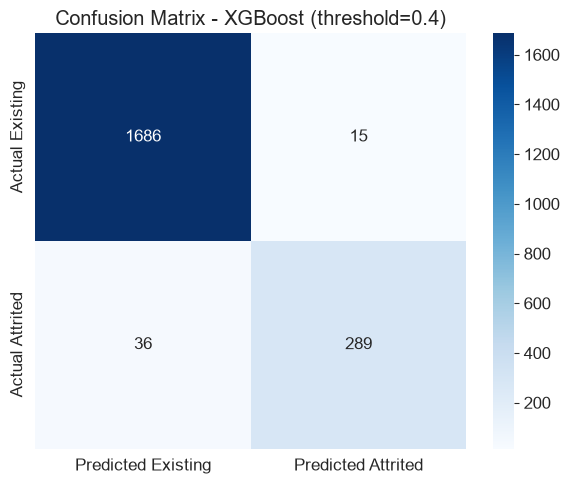


True Negatives  (correctly kept as Existing):  1686
False Positives (wrongly flagged as Attrited):  15
False Negatives (MISSED churners):              36
True Positives  (correctly caught churners):    289

Missed churner rate: 36/325 = 11.1%


In [94]:
# ============================================
# Cell: Confusion Matrix - Final Model
# ============================================
cm = confusion_matrix(y_test, final_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Existing', 'Predicted Attrited'],
            yticklabels=['Actual Existing', 'Actual Attrited'], ax=ax)
plt.title(f'Confusion Matrix - XGBoost (threshold={final_threshold})')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly kept as Existing):  {tn}")
print(f"False Positives (wrongly flagged as Attrited):  {fp}")
print(f"False Negatives (MISSED churners):              {fn}")
print(f"True Positives  (correctly caught churners):    {tp}")
print(f"\nMissed churner rate: {fn}/{fn+tp} = {fn/(fn+tp)*100:.1f}%")

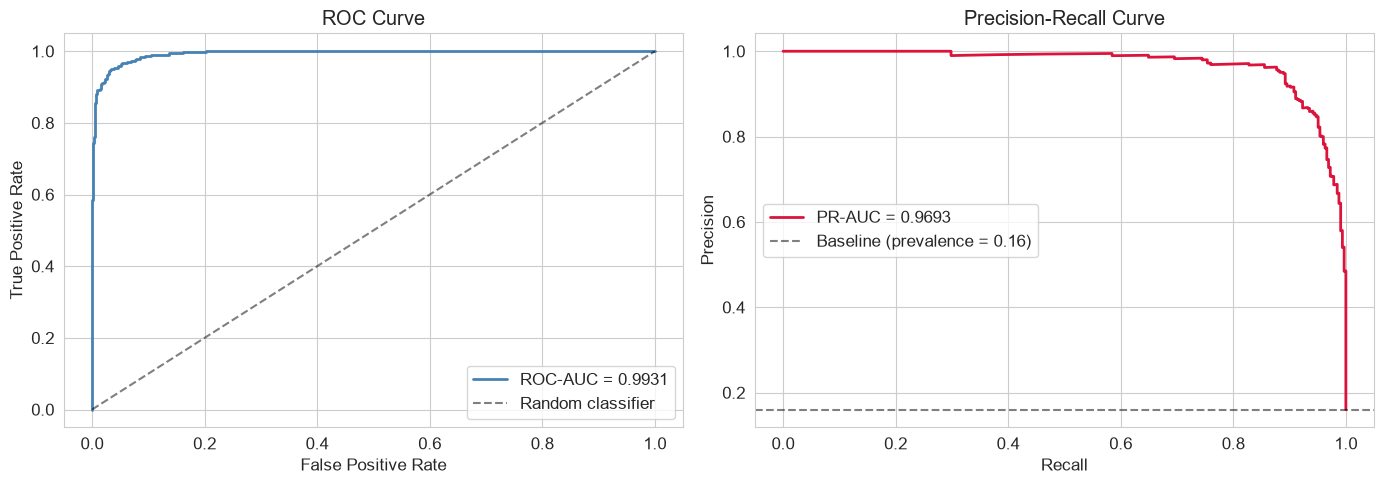

In [95]:
# ============================================
# Cell: ROC Curve and PR Curve - Side by Side
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, final_proba)
ax1.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'ROC-AUC = {roc_auc_score(y_test, final_proba):.4f}')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random classifier')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()

# Precision-Recall Curve
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, final_proba)
ax2.plot(recalls, precisions, color='crimson', linewidth=2,
         label=f'PR-AUC = {pr_auc:.4f}')
ax2.axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5,
            label=f'Baseline (prevalence = {y_test.mean():.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()

plt.tight_layout()
plt.show()

#### Gender Fairness Audit

In [96]:
# ============================================
# Cell: Gender Fairness Audit
# ============================================

# Reconstruct gender labels for the test set
# Gender_M is in X_test - 1 = Male, 0 = Female
gender_test = X_test['Gender_M']

for gender_val, gender_label in [(1,'Male'),(0,'Female')]:
    mask = gender_test == gender_val
    y_true_group = y_test[mask]
    y_pred_group = final_preds[mask]
    y_proba_group = final_proba[mask]

    cm_group = confusion_matrix(y_true_group, y_pred_group)
    tn_g, fp_g, fn_g, tp_g = cm_group.ravel()
    
    recall_g = recall_score(y_true_group, y_pred_group)
    precision_g = precision_score(y_true_group, y_pred_group)
    f1_g = f1_score(y_true_group, y_pred_group)
    fn_rate = fn_g / (fn_g + tp_g)

    print(f"\n{gender_label} (n={mask.sum()}, actual churners={y_true_group.sum()}):")
    print(f"  Recall:             {recall_g:.4f}")
    print(f"  Precision:          {precision_g:.4f}")
    print(f"  F1-Score:           {f1_g:.4f}")
    print(f"  False Negative Rate: {fn_rate:.4f} ({fn_g} missed out of {fn_g+tp_g} actual churners)")

print(f"\n{'─' * 60}")
print("INTERPRETATION GUIDE:")
print("If FN rates differ substantially between groups, the model")
print("systematically catches churn better for one gender than the other,")
print("meaning one group would receive less retention outreach.")

    


Male (n=940, actual churners=144):
  Recall:             0.8750
  Precision:          0.9545
  F1-Score:           0.9130
  False Negative Rate: 0.1250 (18 missed out of 144 actual churners)

Female (n=1086, actual churners=181):
  Recall:             0.9006
  Precision:          0.9477
  F1-Score:           0.9235
  False Negative Rate: 0.0994 (18 missed out of 181 actual churners)

────────────────────────────────────────────────────────────
INTERPRETATION GUIDE:
If FN rates differ substantially between groups, the model
systematically catches churn better for one gender than the other,
meaning one group would receive less retention outreach.


In [97]:
income_test = X_test['Income_Category_encoded']

print("=" * 60)
print("PROXY CHECK: FN Rate by Gender × Income Category")
print("=" * 60)

for income_val in sorted(income_test.unique()):
    income_mask = income_test == income_val
    
    print(f"\nIncome Category {int(income_val)}:")
    
    for gender_val, gender_label in [(1, 'Male'), (0, 'Female')]:
        mask = (gender_test == gender_val) & income_mask
        y_true_group = y_test[mask]
        y_pred_group = final_preds[mask]
        
        if y_true_group.sum() < 5:
            print(f"  {gender_label}: too few churners (n={y_true_group.sum()}) to evaluate reliably")
            continue
        
        cm_g = confusion_matrix(y_true_group, y_pred_group)
        tn_g, fp_g, fn_g, tp_g = cm_g.ravel()
        fn_rate = fn_g / (fn_g + tp_g)
        print(f"  {gender_label}: FN rate = {fn_rate:.4f} ({fn_g} missed / {fn_g+tp_g} churners, n_total={mask.sum()})")

PROXY CHECK: FN Rate by Gender × Income Category

Income Category 0:
  Male: FN rate = 0.1429 (1 missed / 7 churners, n_total=56)
  Female: FN rate = 0.0940 (11 missed / 117 churners, n_total=673)

Income Category 1:
  Male: too few churners (n=0) to evaluate reliably
  Female: FN rate = 0.0588 (2 missed / 34 churners, n_total=218)

Income Category 2:
  Male: FN rate = 0.0952 (2 missed / 21 churners, n_total=145)
  Female: FN rate = 0.1667 (5 missed / 30 churners, n_total=195)

Income Category 3:
  Male: FN rate = 0.1875 (6 missed / 32 churners, n_total=266)
  Female: too few churners (n=0) to evaluate reliably

Income Category 4:
  Male: FN rate = 0.1111 (7 missed / 63 churners, n_total=326)
  Female: too few churners (n=0) to evaluate reliably

Income Category 5:
  Male: FN rate = 0.0952 (2 missed / 21 churners, n_total=139)
  Female: too few churners (n=0) to evaluate reliably


In [98]:
# ============================================
# Cell: Rigorous threshold selection on TRAINING data only
# ============================================
from sklearn.model_selection import cross_val_predict

train_proba_oof = cross_val_predict(
    xgb_model,
    X_train_tree_df,
    y_train,
    cv=skf,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

print(f"{'Threshold':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 44)

best_f1 = -1
best_threshold = 0.5

for t in np.arange(0.20, 0.55, 0.05):
    preds_t = (train_proba_oof >= t).astype(int)
    p = precision_score(y_train, preds_t)
    r = recall_score(y_train, preds_t)
    f1 = f1_score(y_train, preds_t)
    marker = " ← best F1" if f1 > best_f1 else ""
    print(f"{t:<12.2f} {p:>10.4f} {r:>10.4f} {f1:>10.4f}{marker}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nCommitted threshold: {best_threshold:.2f}")

Threshold     Precision     Recall         F1
--------------------------------------------
0.20             0.8665     0.9470     0.9050 ← best F1
0.25             0.8812     0.9401     0.9097 ← best F1
0.30             0.8952     0.9316     0.9131 ← best F1
0.35             0.9094     0.9178     0.9136 ← best F1
0.40             0.9213     0.9078     0.9145 ← best F1
0.45             0.9291     0.8963     0.9124
0.50             0.9406     0.8871     0.9130

Committed threshold: 0.40


In [99]:
# ============================================
# Cell: Final committed threshold and definitive evaluation
# ============================================
COMMITTED_THRESHOLD = 0.30

final_preds = (xgb_pred_proba >= COMMITTED_THRESHOLD).astype(int)

print("=" * 60)
print("DEFINITIVE FINAL EVALUATION - XGBoost (untuned)")
print(f"Committed threshold: {COMMITTED_THRESHOLD}")
print(f"Threshold selected via: out-of-fold training predictions (leakage-safe)")
print("=" * 60)
print(classification_report(y_test, final_preds, target_names=['Existing', 'Attrited']))

cm = confusion_matrix(y_test, final_preds)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"\nMissed churner rate: {fn}/{fn+tp} = {fn/(fn+tp)*100:.1f}%")
print(f"PR-AUC: {average_precision_score(y_test, xgb_pred_proba):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_pred_proba):.4f}")

DEFINITIVE FINAL EVALUATION - XGBoost (untuned)
Committed threshold: 0.3
Threshold selected via: out-of-fold training predictions (leakage-safe)
              precision    recall  f1-score   support

    Existing       0.98      0.98      0.98      1701
    Attrited       0.92      0.90      0.91       325

    accuracy                           0.97      2026
   macro avg       0.95      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026

True Negatives:  1675
False Positives: 26
False Negatives: 34
True Positives:  291

Missed churner rate: 34/325 = 10.5%
PR-AUC: 0.9693
ROC-AUC: 0.9931


In [100]:
# ============================================
# Cell: Update FINAL_MODEL_CONFIG
# ============================================
FINAL_MODEL_CONFIG = {
    'model_type': 'XGBClassifier',
    'xgboost_version': '2.1.1',
    'version': 'untuned (Phase 8 defaults)',
    'n_estimators': 300,
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'decision_threshold': COMMITTED_THRESHOLD,
    'threshold_method': 'F1-optimal on out-of-fold training predictions (cross_val_predict)',
    'pipeline': 'tree (raw features, no scaling)',
    'features_used': X_train_tree_df.columns.tolist()
}

print("FINAL MODEL CONFIGURATION:")
for key, value in FINAL_MODEL_CONFIG.items():
    print(f"  {key}: {value}")

FINAL MODEL CONFIGURATION:
  model_type: XGBClassifier
  xgboost_version: 2.1.1
  version: untuned (Phase 8 defaults)
  n_estimators: 300
  max_depth: 4
  learning_rate: 0.1
  subsample: 0.8
  colsample_bytree: 0.8
  random_state: 42
  decision_threshold: 0.3
  threshold_method: F1-optimal on out-of-fold training predictions (cross_val_predict)
  pipeline: tree (raw features, no scaling)
  features_used: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'is_min_credit_limit', 'high_risk_segment', 'Education_Level_encoded', 'Income_Category_encoded', 'Gender_M', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Unknown', 'Card_Category_grouped_Other']


### Phase 12: Explainability

In [101]:
import xgboost
import shap
print(f"XGBoost version: {xgboost.__version__}")
print(f"SHAP version: {shap.__version__}")

XGBoost version: 2.1.1
SHAP version: 0.52.0


In [102]:
# ============================================
# Cell: SHAP TreeExplainer on our final, committed model
# ============================================
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_tree_df)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Test set shape: {X_test_tree_df.shape}")

SHAP values shape: (2026, 22)
Test set shape: (2026, 22)


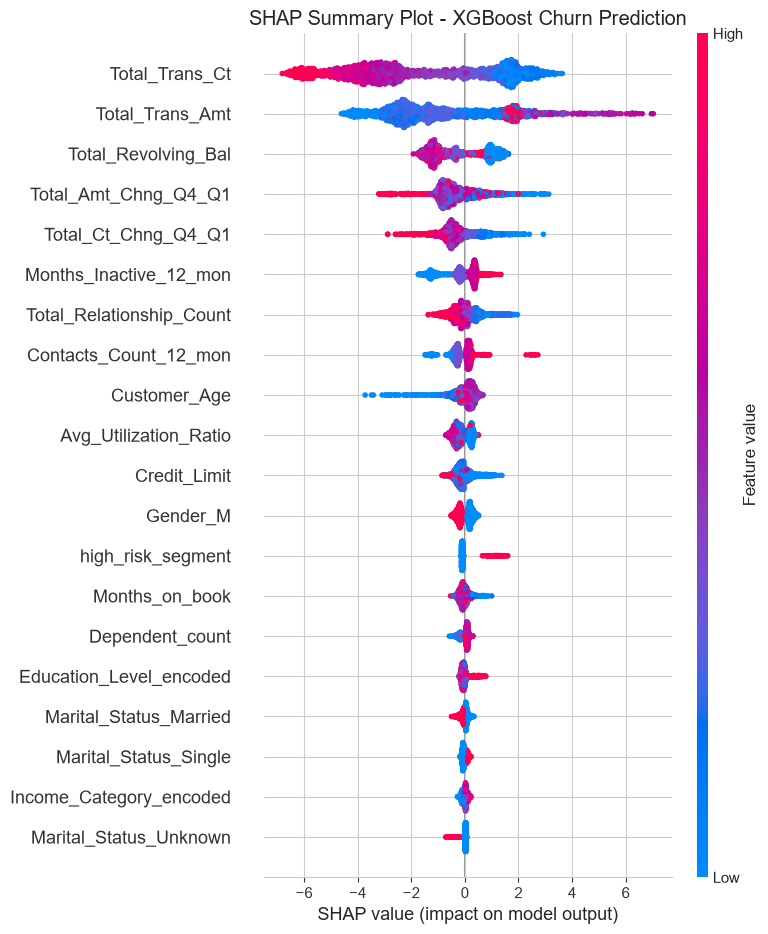

In [103]:
# ============================================
# Cell: SHAP Summary Plot - Global Feature Importance
# ============================================
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_tree_df, show=False)
plt.title('SHAP Summary Plot - XGBoost Churn Prediction')
plt.tight_layout()
plt.show()

In [104]:
# ============================================
# Cell: Identify True Positive, False Negative, False Positive examples
# ============================================
final_preds = (xgb_pred_proba >= COMMITTED_THRESHOLD).astype(int)

tp_indices = np.where((final_preds == 1) & (y_test.values == 1))[0]
fn_indices = np.where((final_preds == 0) & (y_test.values == 1))[0]
fp_indices = np.where((final_preds == 1) & (y_test.values == 0))[0]

print(f"True Positives:  {len(tp_indices)}")
print(f"False Negatives: {len(fn_indices)}")
print(f"False Positives: {len(fp_indices)}")

True Positives:  291
False Negatives: 34
False Positives: 26


Predicted probability: 0.991 (Actual: Attrited, Predicted: Attrited)


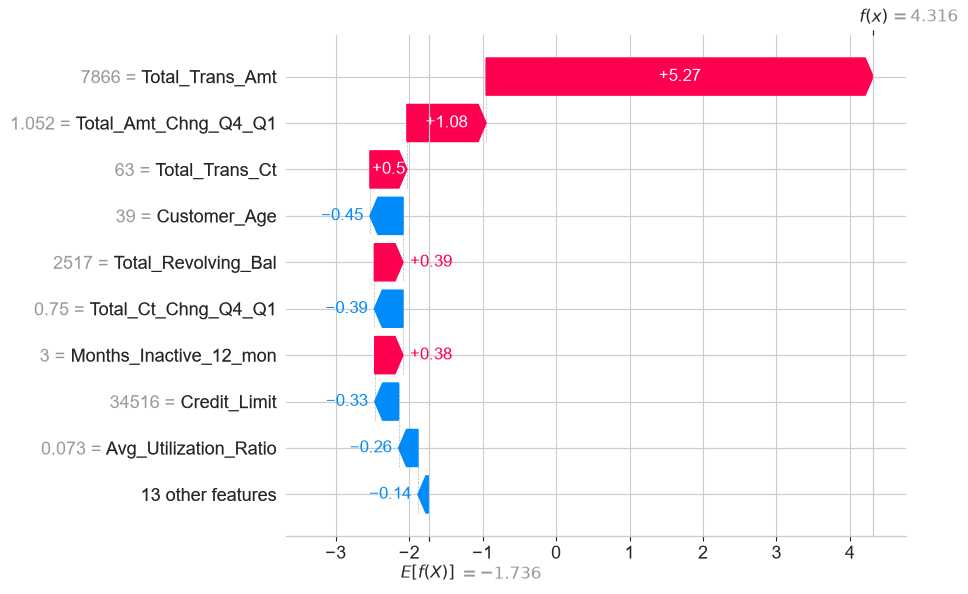

In [105]:
# ============================================
# Cell: Waterfall plot - a correctly caught churner
# ============================================
shap_explanation = explainer(X_test_tree_df)

tp_idx = tp_indices[0]
print(f"Predicted probability: {xgb_pred_proba[tp_idx]:.3f} (Actual: Attrited, Predicted: Attrited)")
shap.plots.waterfall(shap_explanation[tp_idx], show=True)

Predicted probability: 0.013 (Actual: Attrited, Predicted: Existing — MISSED)


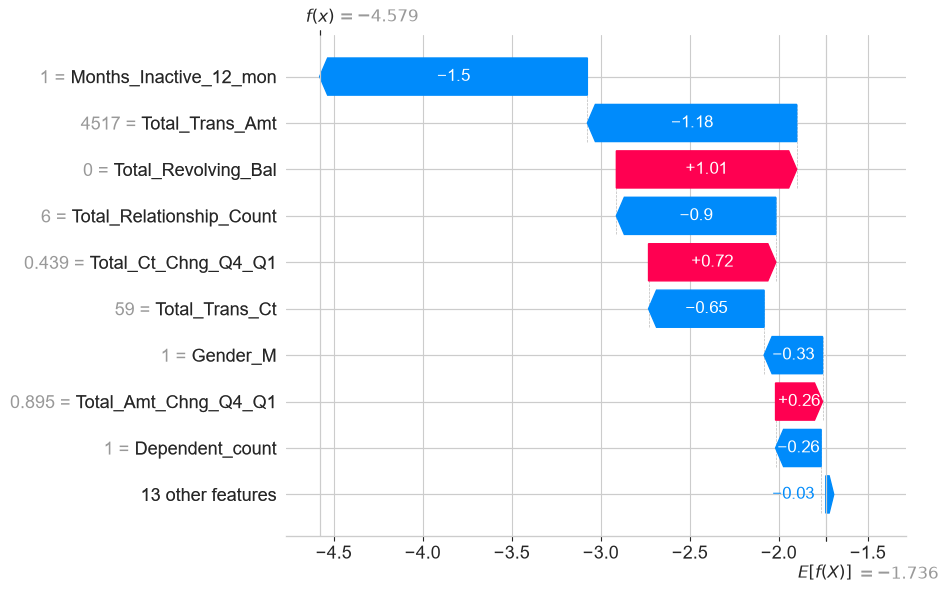

In [106]:
# ============================================
# Cell: Waterfall plot - a missed churner
# ============================================
fn_idx = fn_indices[0]
print(f"Predicted probability: {xgb_pred_proba[fn_idx]:.3f} (Actual: Attrited, Predicted: Existing — MISSED)")
shap.plots.waterfall(shap_explanation[fn_idx], show=True)

### Phase 13 : Error Analysis

In [107]:
# ============================================
# Cell: Build the error analysis working table
# ============================================
error_df = X_test_tree_df.copy()
error_df['actual'] = y_test.values
error_df['predicted_proba'] = xgb_pred_proba
error_df['predicted'] = final_preds
error_df['gender'] = X_test['Gender_M'].values

def classify(row):
    if row['actual'] == 0 and row['predicted'] == 0:
        return 'True Negative'
    elif row['actual'] == 1 and row['predicted'] == 0:
        return 'False Negative'
    elif row['actual'] == 0 and row['predicted'] == 1:
        return 'False Positive'
    else:
        return 'True Positive'

error_df['error_type'] = error_df.apply(func=classify,axis=1)

print(error_df['error_type'].value_counts())
error_df        

error_type
True Negative     1675
True Positive      291
False Negative      34
False Positive      26
Name: count, dtype: int64


,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,is_min_credit_limit,high_risk_segment,Education_Level_encoded,Income_Category_encoded,Gender_M,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_grouped_Other,actual,predicted_proba,predicted,gender,error_type
2919,65.00,0.00,56.00,4.00,2.00,2.00,3226.00,2073.00,1.03,3250.00,70.00,0.59,0.64,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0,0.00,0,1,True Negative
9301,41.00,3.00,30.00,2.00,1.00,1.00,11463.00,0.00,0.91,14511.00,105.00,0.72,0.00,0.00,0.00,4.00,0.00,0.00,0.00,1.00,0.00,1.00,0,0.00,0,0,True Negative
2936,31.00,0.00,21.00,5.00,2.00,2.00,1677.00,0.00,1.37,3059.00,50.00,0.61,0.00,0.00,0.00,3.00,0.00,0.00,1.00,0.00,0.00,0.00,0,0.23,0,0,True Negative
8134,51.00,1.00,36.00,2.00,1.00,1.00,1438.30,468.00,0.75,4425.00,81.00,1.08,0.33,1.00,0.00,2.00,2.00,0.00,1.00,0.00,0.00,0.00,0,0.00,0,0,True Negative
5902,51.00,3.00,41.00,6.00,2.00,3.00,1519.00,1148.00,0.77,4927.00,73.00,0.74,0.76,0.00,0.00,4.00,0.00,0.00,0.00,1.00,0.00,0.00,0,0.00,0,0,True Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5520,44.00,2.00,33.00,3.00,2.00,2.00,2417.00,0.00,0.39,1848.00,38.00,0.41,0.00,0.00,0.00,4.00,0.00,0.00,1.00,0.00,0.00,0.00,1,0.99,1,0,True Positive
3425,44.00,2.00,30.00,3.00,1.00,4.00,3734.00,0.00,0.95,3144.00,62.00,0.72,0.00,0.00,0.00,2.00,0.00,0.00,1.00,0.00,0.00,0.00,0,0.01,0,0,True Negative
9017,44.00,3.00,36.00,1.00,3.00,2.00,10908.00,0.00,0.98,4883.00,42.00,0.50,0.00,0.00,1.00,1.00,4.00,1.00,1.00,0.00,0.00,0.00,1,1.00,1,1,True Positive
5839,52.00,3.00,46.00,4.00,2.00,2.00,9357.00,1285.00,0.69,4173.00,77.00,0.71,0.14,0.00,0.00,4.00,3.00,1.00,0.00,1.00,0.00,0.00,0,0.00,0,1,True Negative


In [108]:
# ============================================
# Cell: Compare feature averages - TP vs FN (both are real churners)
# ============================================

compare_cols = ['Customer_Age', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
                 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
                 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
                 'Avg_Utilization_Ratio']

comparison = error_df[error_df['error_type'].isin(['True Positive','False Negative'])]
comparison = comparison.groupby(by='error_type')[compare_cols].mean().T
comparison['Differences'] = comparison['False Negative'] - comparison['True Positive']
comparison['% Differences'] = (comparison['Differences'] / comparison['True Positive'] * 100).round(1)

print(comparison.round(2))

error_type                False Negative  True Positive  Differences  \
Customer_Age                       45.68          46.57        -0.89   
Total_Relationship_Count            4.21           3.30         0.91   
Months_Inactive_12_mon              2.15           2.68        -0.53   
Contacts_Count_12_mon               3.00           2.95         0.05   
Credit_Limit                    10027.36        8142.42      1884.95   
Total_Revolving_Bal              1089.62         639.01       450.61   
Total_Trans_Amt                  2885.62        3359.58      -473.96   
Total_Trans_Ct                     50.59          45.74         4.85   
Total_Ct_Chng_Q4_Q1                 0.66           0.54         0.11   
Avg_Utilization_Ratio               0.25           0.18         0.07   

error_type                % Differences  
Customer_Age                      -1.90  
Total_Relationship_Count          27.60  
Months_Inactive_12_mon           -19.80  
Contacts_Count_12_mon              1.90

In [109]:
# ============================================
# Cell: Classify each False Negative as borderline or confident miss
# ============================================
fn_df = error_df[error_df['error_type'] == 'False Negative'].copy()
def marginal_miss(p):
    if p >= 0.20:
        return 'Borderline (0.20-0.30)'
    elif p >= 0.10:
        return 'Moderate (0.10-0.20)'
    else:
        return 'Confident miss (<0.10)'

fn_df['miss_type'] = fn_df['predicted_proba'].apply(marginal_miss)

print(fn_df['miss_type'].value_counts())
print(f"\nFull probability distribution for missed churners:")
print(fn_df['predicted_proba'].describe())

miss_type
Confident miss (<0.10)    13
Moderate (0.10-0.20)      12
Borderline (0.20-0.30)     9
Name: count, dtype: int64

Full probability distribution for missed churners:
count   34.00
mean     0.14
std      0.09
min      0.01
25%      0.04
50%      0.16
75%      0.20
max      0.29
Name: predicted_proba, dtype: float64


In [110]:
# ============================================
# Cell: Compare feature averages - False Positives vs True Negatives
# ============================================
compare_fp = error_df[error_df['error_type'].isin(['True Negative', 'False Positive'])].groupby('error_type')[compare_cols].mean().T
compare_fp['Difference'] = compare_fp['False Positive'] - compare_fp['True Negative']
compare_fp['% Difference'] = (compare_fp['Difference'] / compare_fp['True Negative'] * 100).round(1)

print(compare_fp.round(2))

error_type                False Positive  True Negative  Difference  \
Customer_Age                       45.00          46.01       -1.01   
Total_Relationship_Count            3.88           3.91       -0.02   
Months_Inactive_12_mon              2.46           2.26        0.20   
Contacts_Count_12_mon               3.04           2.34        0.69   
Credit_Limit                     6964.58        8965.49    -2000.91   
Total_Revolving_Bal               626.77        1240.13     -613.36   
Total_Trans_Amt                  2654.19        4721.02    -2066.83   
Total_Trans_Ct                     47.27          69.50      -22.23   
Total_Ct_Chng_Q4_Q1                 0.61           0.74       -0.13   
Avg_Utilization_Ratio               0.17           0.29       -0.12   

error_type                % Difference  
Customer_Age                     -2.20  
Total_Relationship_Count         -0.50  
Months_Inactive_12_mon            8.90  
Contacts_Count_12_mon            29.60  
Credit_Limit 

In [111]:
# ============================================
# Cell: Error type distribution by gender - corrected normalization
# ============================================
raw_counts = pd.crosstab(error_df['gender'], error_df['error_type']).rename(index={0: 'Female', 1: 'Male'})
print("Raw counts:")
print(raw_counts)

print("\nAs % within each ERROR TYPE (columns sum to 100%):")
pct_by_error_type = pd.crosstab(error_df['gender'], error_df['error_type'], normalize='columns') * 100
pct_by_error_type.index = ['Female', 'Male']
print(pct_by_error_type.round(1))

Raw counts:
error_type  False Negative  False Positive  True Negative  True Positive
gender                                                                  
Female                  16              15            890            165
Male                    18              11            785            126

As % within each ERROR TYPE (columns sum to 100%):
error_type  False Negative  False Positive  True Negative  True Positive
Female               47.10           57.70          53.10          56.70
Male                 52.90           42.30          46.90          43.30


### Phase 14 Production Pipeline

In [112]:
pipeline = Pipeline([('preprocessor',preprocessor_tree),("model",xgb_model)])
pipeline.fit(X_train_tree_df,y_train)
joblib.dump(pipeline,'final_pipeline.pkl')
print('Pipeline saved successfully')
                    

Pipeline saved successfully


In [113]:
pipeline = joblib.load('final_pipeline.pkl')
print('model loaded successfully')

model loaded successfully


In [114]:
### lets check it for a sample from test set
#Test Set for 2919
rand_test_index = 5520

testt = X_test_tree_df[X_test_tree_df.index == rand_test_index]

print("Actual value : ")
print(y_test[y_test.index == rand_test_index])# actual class : 0
print("\n")
print("Prediction Prob:")
print(error_df[error_df.index == rand_test_index]['predicted_proba']) ## probability : 0.00
print("\n")
print("Prediction Class:")
print(error_df[error_df.index == rand_test_index]['predicted']) # predicted class : 0.00



Actual value : 
5520    1
Name: churn, dtype: int64


Prediction Prob:
5520   0.99
Name: predicted_proba, dtype: float32


Prediction Class:
5520    1
Name: predicted, dtype: int64


In [115]:
print("Pipeline Prediction Prob:")
print(pipeline.predict(testt)) # resulted 0
print("Pipeline Prediction Class:")
print(pipeline.predict_proba(testt)[0][1])

Pipeline Prediction Prob:
[1]
Pipeline Prediction Class:
0.9903127


In [116]:
error_df['Pipe_predict_prob'] = pipeline.predict_proba(X_test_tree_df)[:,1]
(error_df['predicted_proba'] == error_df['Pipe_predict_prob']).all()

np.True_